# 1. Connection to the Database & Libraries

In [1]:
# pip install --upgrade google-cloud-bigquery

# from google.colab import auth
from google.cloud import bigquery
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

In [2]:
# connection to big query
# auth.authenticate_user()

client = bigquery.Client(project="data-analytics-mate")

/Users/kovalskyy/Downloads/Portfolio Project 1 (Mate)/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


# 2. Data Collection & Cleaning

## 2.1 Data Collection

In [3]:
# sql query
query = """
with session_info as (
SELECT
      s.date,
      sp.ga_session_id as session_id,
      sp.continent,
      sp.country,
      sp.device,
      sp.browser,
      sp.mobile_model_name as device_model,
      sp.operating_system as system,
      sp.language,
      sp.channel

FROM data-analytics-mate.DA.session s
JOIN data-analytics-mate.DA.session_params sp
ON s.ga_session_id = sp.ga_session_id
),

account_info as (
SELECT
      acs.ga_session_id as account_session_id,
      ac.id as account_id,
      ac.is_verified as confirmed_email,
      ac.is_unsubscribed

FROM data-analytics-mate.DA.account ac
JOIN data-analytics-mate.DA.account_session acs
ON ac.id = acs.account_id
),

order_info as (
SELECT
      o.ga_session_id as order_session_id,
      p.category,
      p.name as product_name,
      p.price,
      p.short_description as product_description

FROM data-analytics-mate.DA.order o
LEFT JOIN data-analytics-mate.DA.product p
ON o.item_id = p.item_id
)

SELECT
      si.date,
      si.session_id,
      si.continent,
      si.country,
      si.device,
      si.browser,
      si.device_model,
      si.system,
      si.language,
      si.channel,
      aci.account_id,
      aci.confirmed_email,
      aci.is_unsubscribed,
      oi.category,
      oi.product_name,
      oi.price,
      oi.product_description

FROM session_info si
LEFT JOIN account_info aci
ON si.session_id = aci.account_session_id
LEFT JOIN order_info oi
ON si.session_id = oi.order_session_id
"""

# creating dataframe
query_job = client.query(query)
results = query_job.result()

df = pd.DataFrame(
    [tuple(row) for row in results],
    columns=[field.name for field in results.schema]
)

df.head()

,date,session_id,continent,country,device,browser,device_model,system,language,channel,account_id,confirmed_email,is_unsubscribed,category,product_name,price,product_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,Paid Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,Organic Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,Direct,NaN,NaN,NaN,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 349545 non-null  object 
 1   session_id           349545 non-null  int64  
 2   continent            349545 non-null  str    
 3   country              349545 non-null  str    
 4   device               349545 non-null  str    
 5   browser              349545 non-null  str    
 6   device_model         349545 non-null  str    
 7   system               349545 non-null  str    
 8   language             235279 non-null  str    
 9   channel              349545 non-null  str    
 10  account_id           27945 non-null   float64
 11  confirmed_email      27945 non-null   float64
 12  is_unsubscribed      27945 non-null   float64
 13  category             33538 non-null   str    
 14  product_name         33538 non-null   str    
 15  price                33538 n

**Comments:**

After getting all the necessary data and converting it into the DataFrame total number of rows corresponds to the correct amount, considering our planned grain. Account info and order info were joined using LEFT JOIN, as there may be no order or/and account linked with the particular session. 

## 2.2 Data Cleaning

In [5]:
# changing column dtypes
df["date"] = df["date"].astype("datetime64[ns]")

df[["session_id", "account_id"]] = df[["session_id", "account_id"]].astype("string")

df[["confirmed_email", "is_unsubscribed"]] = df[["confirmed_email", "is_unsubscribed"]].astype("Int64")

df.dtypes

date                   datetime64[ns]
session_id                     string
continent                         str
country                           str
device                            str
browser                           str
device_model                      str
system                            str
language                          str
channel                           str
account_id                     string
confirmed_email                 Int64
is_unsubscribed                 Int64
category                          str
product_name                      str
price                         float64
product_description               str
dtype: object

In [6]:
# cheking nan values
df.isna().sum()

df["language"] = df["language"].fillna("Unknown")

df.isna().sum()

date                        0
session_id                  0
continent                   0
country                     0
device                      0
browser                     0
device_model                0
system                      0
language                    0
channel                     0
account_id             321600
confirmed_email        321600
is_unsubscribed        321600
category               316007
product_name           316007
price                  316007
product_description    316007
dtype: int64

In [7]:
# cheking duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
# checking consistency between browser and device_model
print(
    "Rows where device_model equals browser:",
    (df["device_model"] == df["browser"]).sum()
)

print(
    "Rows where device_model is a browser value:",
    df["device_model"].isin(df["browser"].unique()).sum()
)

# Safari inconsistencies
safari_mask = (
    (df["browser"] == "Safari") &
    ~df["device_model"].isin(["iPhone", "iPad"])
)

print("\nDevice models for Safari inconsistencies:")
print(df.loc[safari_mask, "device_model"].value_counts())

# Chrome inconsistencies
chrome_mask = (
    (df["browser"] == "Chrome") &
    ~df["device_model"].isin(["Chrome", "ChromeBook"])
)

print("\nDevice models for Chrome inconsistencies:")
print(df.loc[chrome_mask, "device_model"].value_counts())

Rows where device_model equals browser: 134383
Rows where device_model is a browser value: 251765

Device models for Safari inconsistencies:
device_model
Safari     16151
<Other>      323
Name: count, dtype: int64

Device models for Chrome inconsistencies:
device_model
<Other>       57514
Safari        53313
iPhone         7134
iPad           1919
Pixel 4 XL     1222
Pixel 3        1016
Edge              6
Name: count, dtype: int64


In [9]:
# checking number of unique sessions
print("Number of sessions: ", df["session_id"].shape[0])
print("Number of unique sessions: ", df["session_id"].unique().shape[0])

Number of sessions:  349545
Number of unique sessions:  349545


In [10]:
# checking data set date range
print(f"Dataset date range: {df["date"].min().date()} to {df["date"].max().date()}")

Dataset date range: 2020-11-01 to 2021-01-31


**Comments:**

* Missing values in the accounts-related fields are consistent across columns and correspond to sessions from unregistered users. Similarly, missing values in the orders-related fields are aligned across columns, indicating sessions in which no order was placed. Therefore, these missing values represent the underlying session state rather than data-quality issues.

* Inconsistencies were identified between the `browser` and `device_model` fields. Since there is insufficient evidence to determine which values are incorrect, the original `device_model` data was retained. However, due to inconsistent labeling, this field will be excluded from analytical comparisons and conclusions based on specific device models.

* The `order_session_id` field does not provide additional analytical value, as it contains no unique session identifiers and follows the same missing-value pattern as the other order-related fields. The column was therefore removed from the dataset.

* The dataset covers approximately three months of activity, with each row representing a unique session.

## 2.3 Price Distribution & Outliers

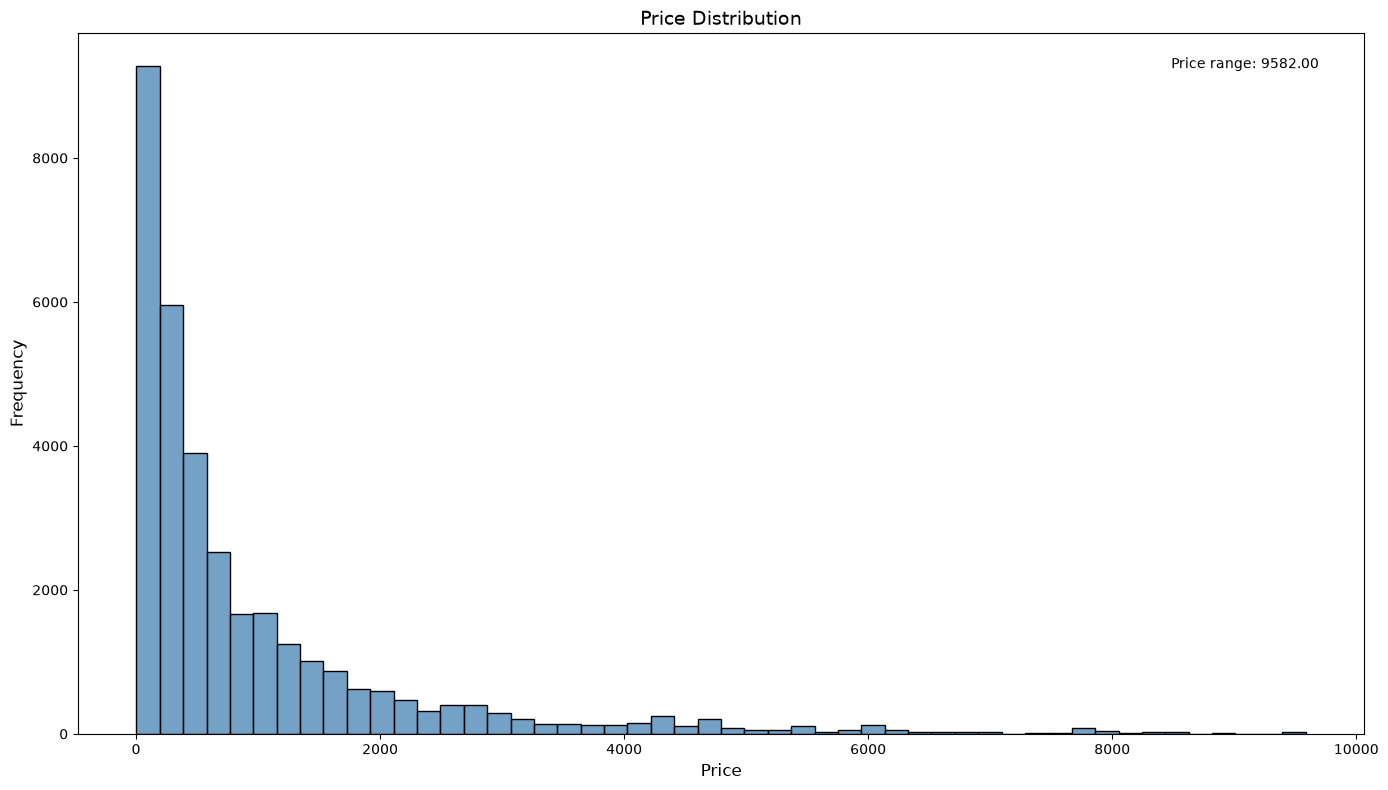

In [11]:
# price column distribution
plt.figure(figsize=(14, 8))

sns.histplot(
    x=df["price"],
    bins=50,
    color="steelblue"
)

plt.title(
    "Price Distribution",
    fontsize=14
)
plt.xlabel(
    "Price",
    fontsize=12
)
plt.ylabel(
    "Frequency",
    fontsize=12
)

price_range = df["price"].max() - df["price"].min()
plt.text(
    0.85, 0.95,
    f"Price range: {price_range:.2f}",
    transform=plt.gca().transAxes
)

plt.tight_layout()
plt.show()

In [12]:
## identifying outliers in price

# IQR method
prices = df["price"].dropna()

q1 = df["price"].quantile(q=0.25)
q2 = df["price"].quantile(q=0.5)
q3 = df["price"].quantile(q=0.75)

iqr = q3 - q1
iqr_lower_bound = q1 - 1.5 * iqr
iqr_upper_bound = q3 + 1.5 * iqr

iqr_outliers = pd.Series(
    [x for x in prices if x < iqr_lower_bound or x > iqr_upper_bound])

print(f"Number of IQR Method outliers: {iqr_outliers.shape[0]}")
print(f"IQR Method outliers compared to all data: {(iqr_outliers.shape[0] / prices.shape[0]):.4%}\n")

# Z-score method
z_score_price = stats.zscore(prices)

z_score_outliers = prices[abs(z_score_price) > 3]

print(f"Number of Z-score Method outliers: {z_score_outliers.shape[0]}")
print(f"Z-score Method outliers compared to all data: {(z_score_outliers.shape[0] / prices.shape[0]):.4%}")

Number of IQR Method outliers: 2826
IQR Method outliers compared to all data: 8.4263%

Number of Z-score Method outliers: 819
Z-score Method outliers compared to all data: 2.4420%


In [13]:
# looking at IQR Method outliers
iqr_outliers = iqr_outliers.sort_values()

print(f"Bottom 5 IQR outliers:\n{iqr_outliers.head()}\n")
print(f"IQR Lower Bound: {iqr_lower_bound}\n")

print(f"Top 5 IQR outliers:\n{iqr_outliers.tail()}\n")
print(f"IQR Upper Bound: {iqr_upper_bound}")

Bottom 5 IQR outliers:
1246    2765.0
442     2765.0
865     2765.0
2167    2765.0
1620    2765.0
dtype: float64

IQR Lower Bound: -1367.5

Top 5 IQR outliers:
2306    9585.0
2241    9585.0
1780    9585.0
666     9585.0
359     9585.0
dtype: float64

IQR Upper Bound: 2732.5


**Conclusion:**

Visual inspection revealed an extremely right-skewed price distribution with a pronounced right tail. To validate the presence of extreme observations, both the IQR and Z-score methods were applied. Given the strong skewness of the distribution, the IQR method was considered more appropriate for identifying potential outliers. It identified observations above 2732.5 as upper-bound outliers, while no lower-bound outliers were detected.

The identified outliers were further inspected using the available product and order information. Since `category`, `name`, and `price` contain the same number of non-null observations, each non-null price corresponds to a product/order record. As there is no evidence that these observations are data errors, the outliers were retained for further analysis.

# 3. Exploratory Data Analysis

## 3.1 Session Analysis

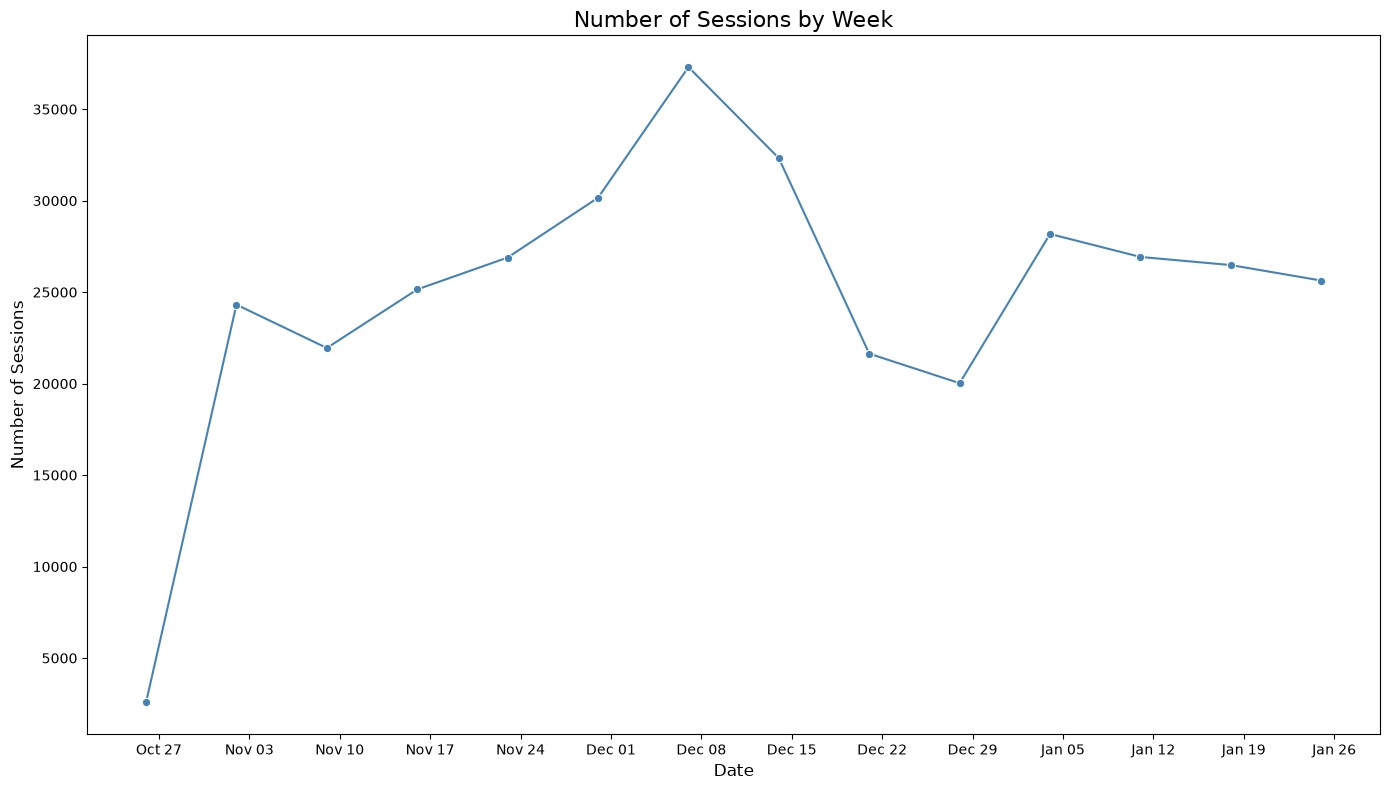

In [14]:
# number of sessions dynamic
session_cnt_date = (
    df.groupby(
        df["date"].dt.to_period("W-SUN")
        .dt.start_time.dt.date, as_index=False)
        ["session_id"]
        .count()
)

plt.figure(figsize=(14, 8))

sns.lineplot(
    x=session_cnt_date["date"],
    y=session_cnt_date["session_id"],
    color="steelblue",
    marker="o"
)

plt.title(
    "Number of Sessions by Week",
    fontsize=16
)
plt.xlabel(
    "Date",
    fontsize=12
)
plt.ylabel(
    "Number of Sessions",
    fontsize=12
)

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

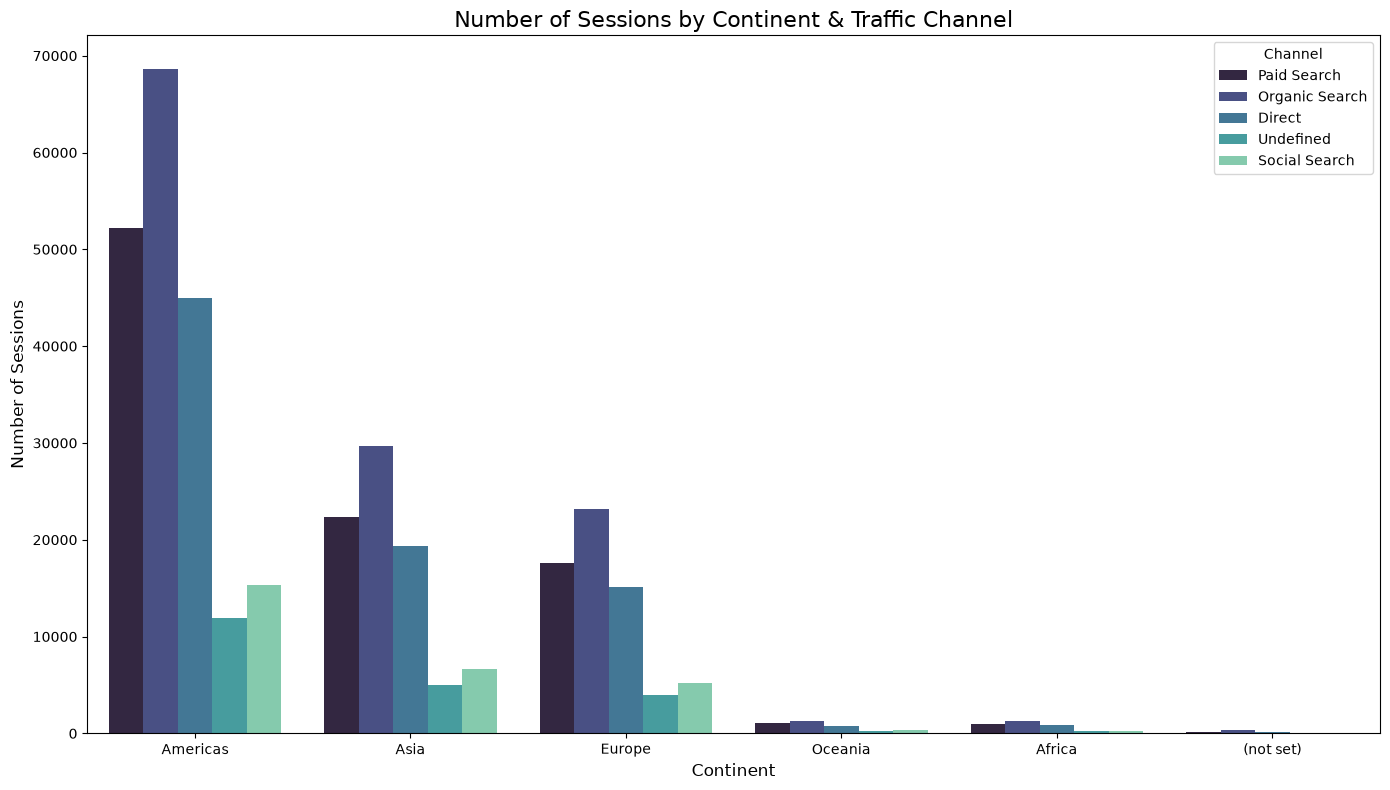

In [15]:
# total sessions by continent
continent_order = df["continent"].value_counts().index

plt.figure(figsize=(14, 8))

sns.countplot(
    x=df["continent"],
    order=continent_order,
    hue=df["channel"],
    palette="mako"
)
plt.title(
    "Number of Sessions by Continent & Traffic Channel",
    fontsize=16
)
plt.xlabel(
    "Continent",
    fontsize=12
)
plt.ylabel(
    "Number of Sessions",
    fontsize=12
)
plt.legend(title="Channel")

plt.tight_layout()
plt.show()

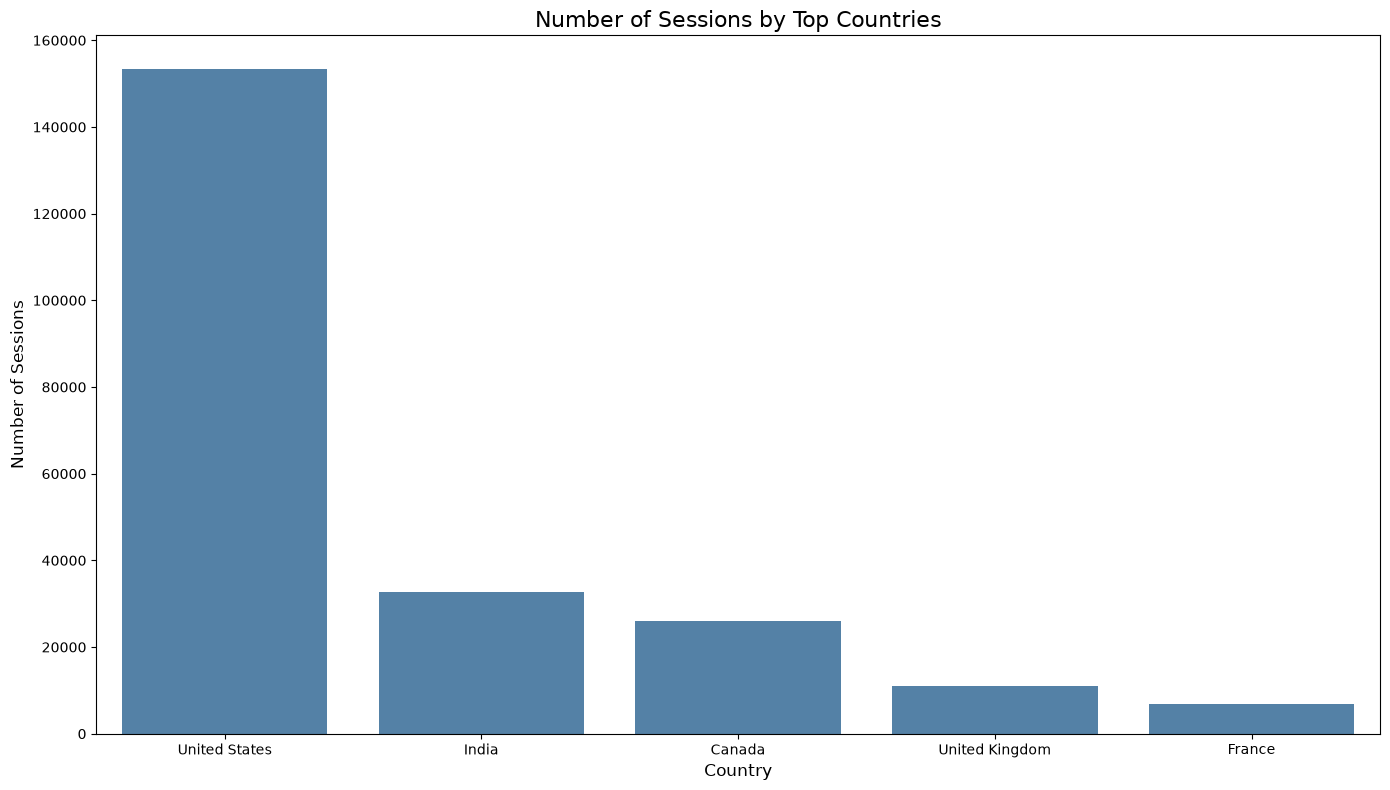

In [16]:
# total sessions by top 5 countries
sessions_top_countries = (df.groupby(
    "country")["session_id"]
    .agg(session_count="count")
    .sort_values(ascending=False, by="session_count")
    .iloc[:5, :]
    .reset_index()
)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=sessions_top_countries["country"],
    y=sessions_top_countries["session_count"],
    errorbar=None,
    color="steelblue"
)
plt.title(
    "Number of Sessions by Top Countries",
    fontsize=16
)
plt.xlabel(
    "Country",
    fontsize=12
)
plt.ylabel(
    "Number of Sessions",
    fontsize=12
)

plt.tight_layout()
plt.show()

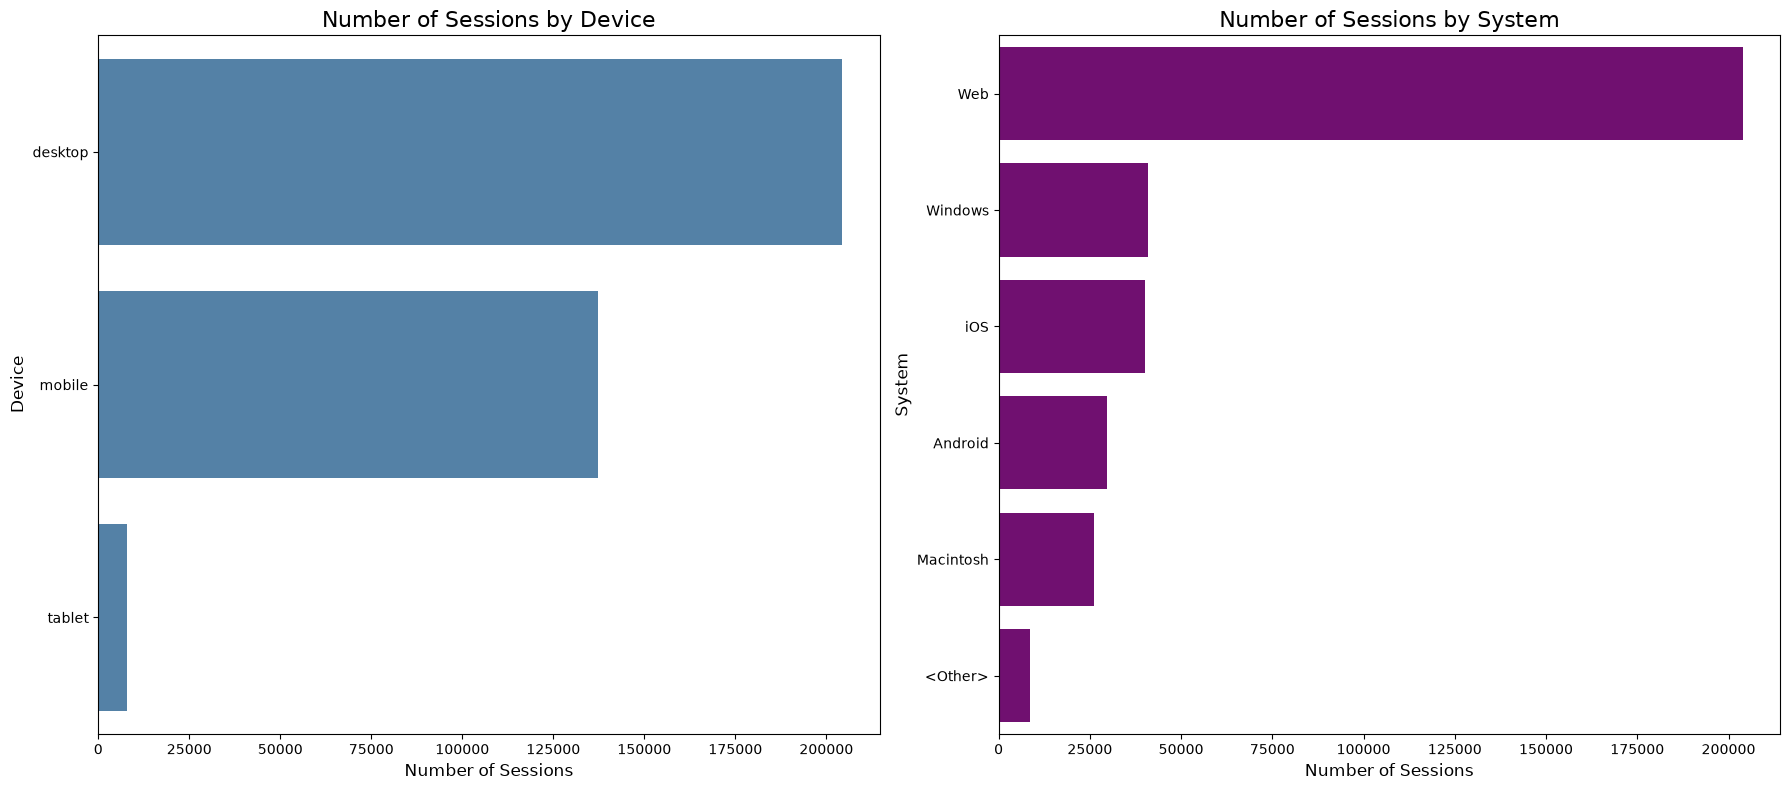

In [17]:
## sessions by devices and system subplot 
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# devices plot
device_order = df["device"].value_counts().index

sns.countplot(
    y=df["device"],
    color="steelblue",
    order=device_order,
    ax=ax[0]
)
ax[0].set_title(
    "Number of Sessions by Device",
    fontsize=16
)
ax[0].set_xlabel(
    "Number of Sessions",
    fontsize=12
)
ax[0].set_ylabel(
    "Device",
    fontsize=12
)

# systems plot 
system_order = df["system"].value_counts().index

sns.countplot(
    y=df["system"],
    color="purple",
    order=system_order,
    ax=ax[1]
)
ax[1].set_title(
    "Number of Sessions by System",
    fontsize=16
)
ax[1].set_xlabel(
    "Number of Sessions",
    fontsize=12
)
ax[1].set_ylabel(
    "System",
    fontsize=12
)

plt.tight_layout()
plt.show()

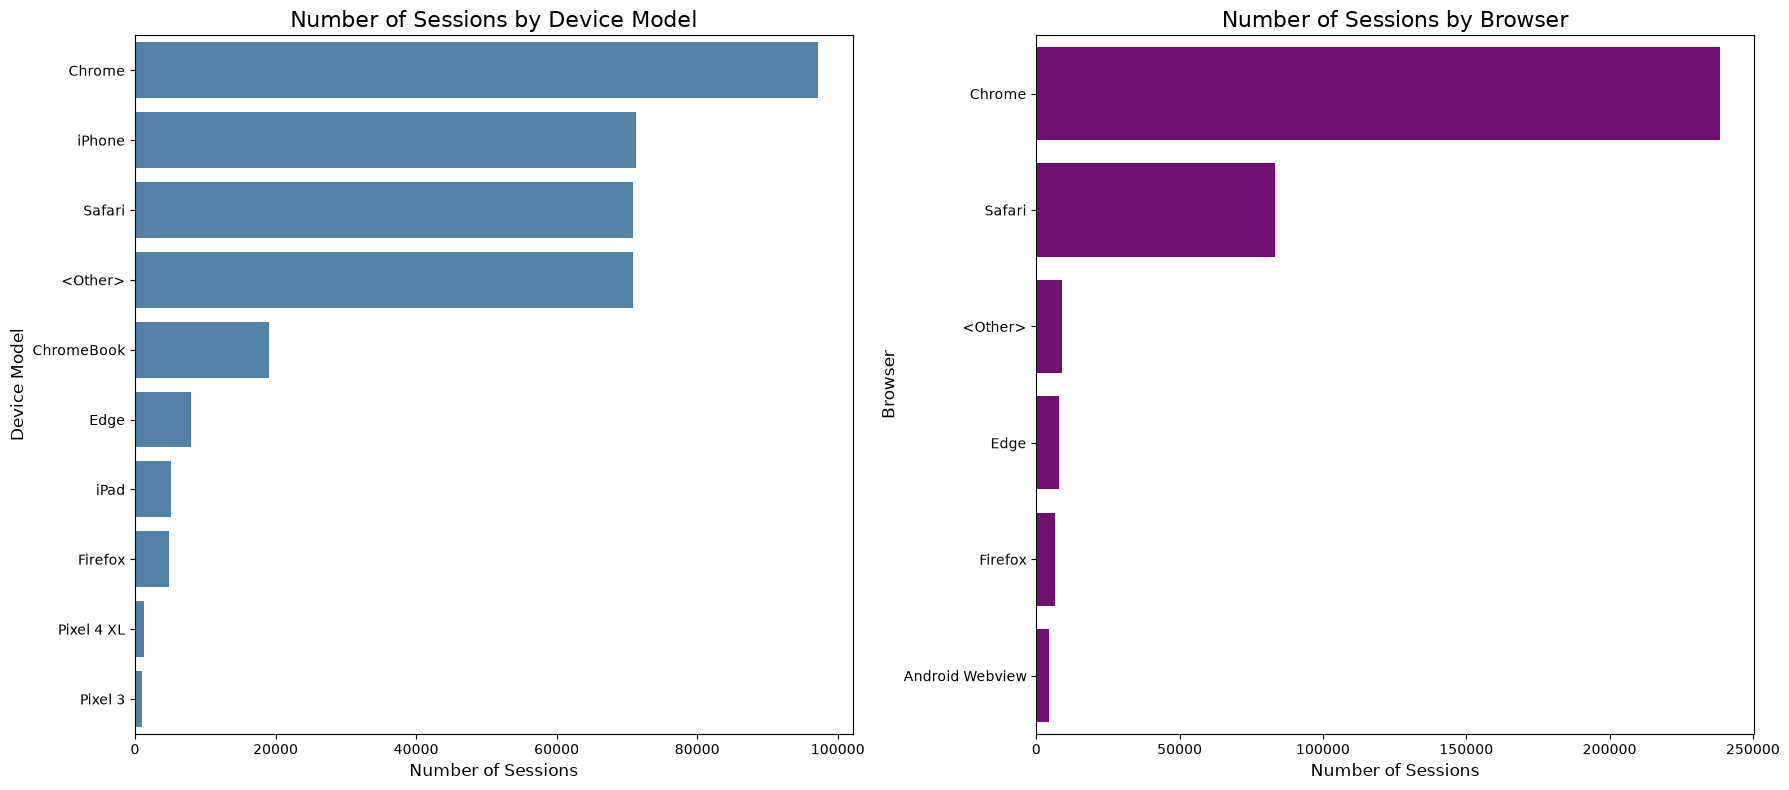

In [18]:
## sessions by device_model and browser subplot
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# device_model plot 
device_model_order = df["device_model"].value_counts().index

sns.countplot(
    y=df["device_model"],
    color="steelblue",
    order=device_model_order,
    ax=ax[0]
)
ax[0].set_title(
    "Number of Sessions by Device Model",
    fontsize=16
)
ax[0].set_xlabel(
    "Number of Sessions",
    fontsize=12
)
ax[0].set_ylabel(
    "Device Model",
    fontsize=12
)

# browser plot
browser_order = df["browser"].value_counts().index

sns.countplot(
    y=df["browser"],
    color="purple",
    order=browser_order,
    ax=ax[1]
)
ax[1].set_title(
    "Number of Sessions by Browser",
    fontsize=16
)
ax[1].set_xlabel(
    "Number of Sessions",
    fontsize=12
)
ax[1].set_ylabel(
    "Browser",
    fontsize=12
)

plt.tight_layout()
plt.show()

**Sessions - Key Findings:**

* Session volume increased steadily through November 2020 and reached a peak in early December. It then dropped by over 40% within two weeks and remained at a relatively stable level through the end of the observation period, with a temporary recovery in early January.

* The Americas generated the highest number of sessions by a substantial margin, followed by Asia and Europe. At the country level, the United States was the dominant market, with India and Canada ranking second and third.

* Organic Search was the leading traffic channel across all continents, while Paid Search and Direct were also major sources of sessions. The overall channel distribution was broadly consistent across regions.

* Desktop was the dominant device category, followed by mobile, while tablet traffic was relatively small. The `Web` system accounted for the majority of sessions, with Windows and iOS being the next most common systems.

* Chrome was the most frequently observed browser by a large margin, followed by Safari, while all other browsers represented a relatively small share of sessions. The `device_model` field was retained but excluded from analytical comparisons due to inconsistencies identified during data-quality checks.

## 3.2 Registrations Analysis

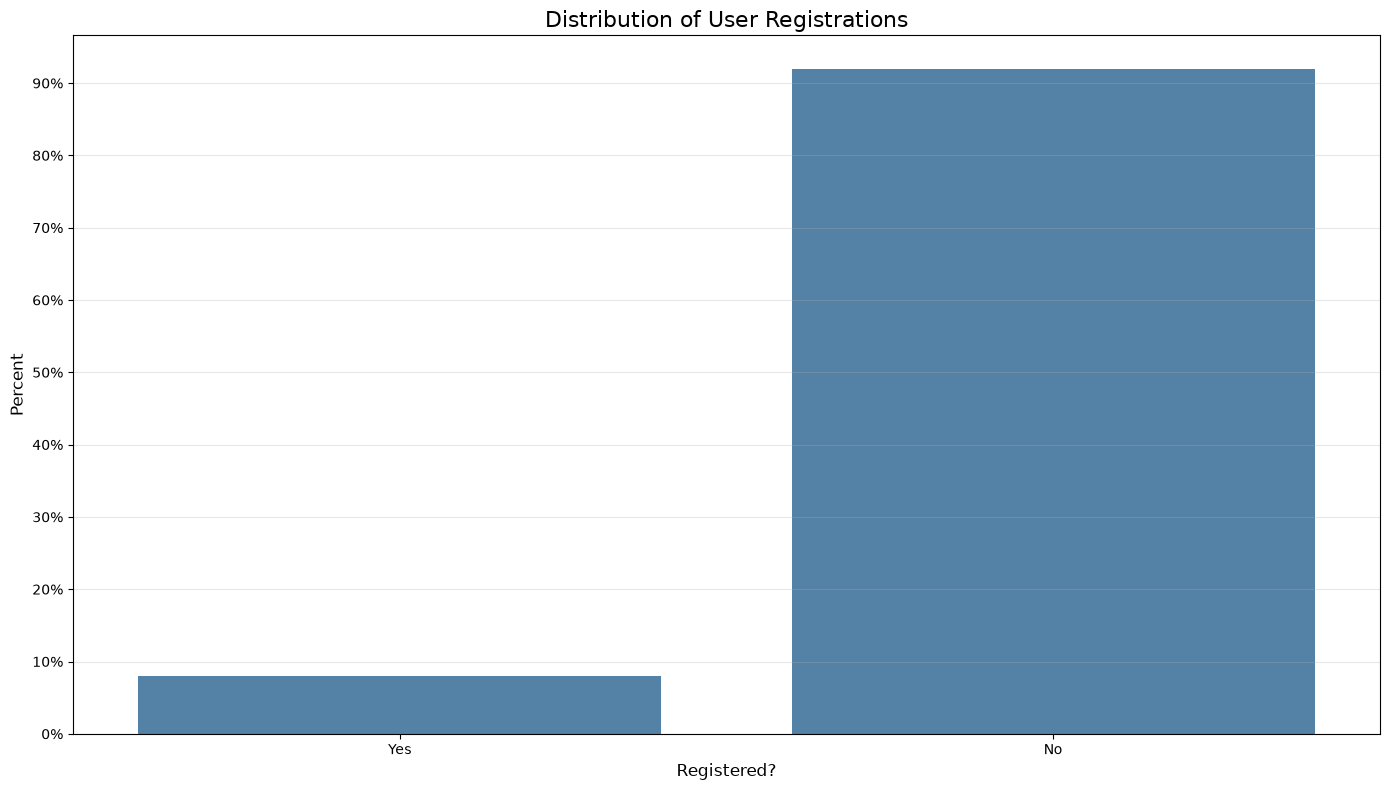

In [19]:
# cheking distribution of registered users against unregistrered
plt.figure(figsize=(14, 8))

sns.countplot(
    x=df["account_id"].isna(),
    stat="percent",
    color="steelblue"
)

plt.title(
    "Distribution of User Registrations",
    fontsize=16
)
plt.xlabel(
    "Registered?",
    fontsize=12
)
plt.ylabel(
    "Percent",
    fontsize=12
)
plt.grid(which="major", axis="y", alpha=0.3)

plt.xticks(ticks=[0, 1], labels=["Yes", "No"])
plt.yticks(np.arange(0, 100, 10))
plt.gca().yaxis.set_major_formatter(PercentFormatter(100))

plt.tight_layout()
plt.show()

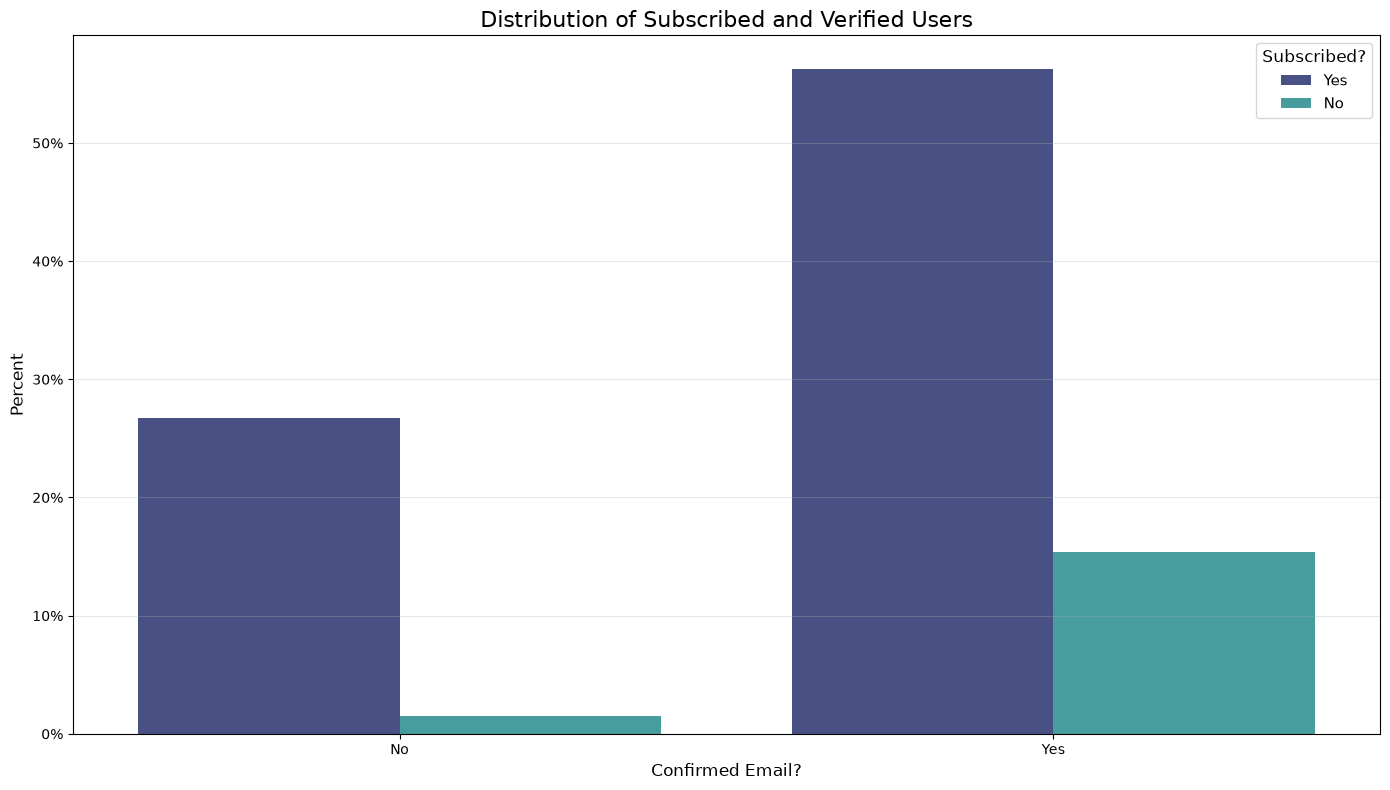

In [20]:
## cheking distribution of verified emails accross registered accounts

# aggregating necessary data
verified_emails = df.loc[(df["account_id"].notna()), ["confirmed_email", "is_unsubscribed"]]

# plotting
plt.figure(figsize=(14, 8))

sns.countplot(
    x=verified_emails["confirmed_email"],
    stat="percent",
    hue=verified_emails["is_unsubscribed"],
    palette="mako"
)

plt.title(
    "Distribution of Subscribed and Verified Users",
    fontsize=16
)
plt.xlabel(
    "Confirmed Email?",
    fontsize=12
)
plt.ylabel(
    "Percent",
    fontsize=12
)
plt.grid(which="major", axis="y", alpha=0.3)

plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.legend(
    title="Subscribed?",
    title_fontsize=12,
    labels=["Yes", "No"],
    fontsize=11
    
)
plt.gca().yaxis.set_major_formatter(PercentFormatter(100))
pd.crosstab(
    verified_emails["confirmed_email"],
    verified_emails["is_unsubscribed"],
    normalize="index"
)

plt.tight_layout()
plt.show()

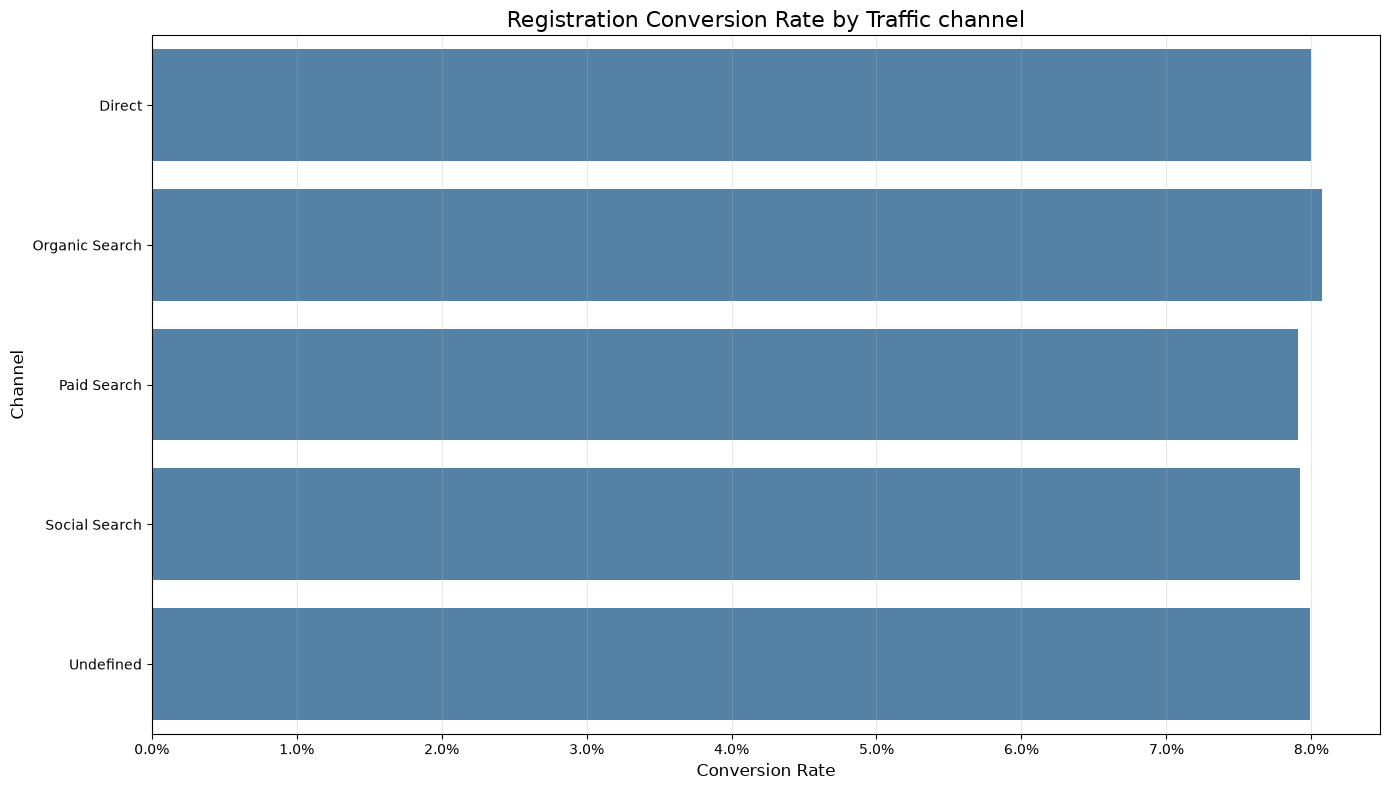

In [21]:
# cheking registration conversion across devices
# in the data set every account has only 1 session, total number of accounts = total unique accounts

# aggregating necessary data
registr_conversion_channel = (
    df.assign(registered=df["account_id"].notna())
      .groupby("channel", as_index=False)
      .agg(
          registered=("registered", "sum"),
          total=("registered", "count")
      )
)

registr_conversion_channel["conversion_rate"] = (
    registr_conversion_channel["registered"]
    / registr_conversion_channel["total"]
).round(4)

# plotting
plt.figure(figsize=(14, 8))

sns.barplot(
    x=registr_conversion_channel["conversion_rate"] * 100,
    y=registr_conversion_channel["channel"],
    color="steelblue"
)
plt.title(
    "Registration Conversion Rate by Traffic channel",
    fontsize=16
)
plt.xlabel(
    "Conversion Rate",
    fontsize=12
)
plt.ylabel(
    "Channel",
    fontsize=12
)
plt.grid(which="major", axis="x", alpha=0.3)

plt.gca().xaxis.set_major_formatter(PercentFormatter(100))

plt.tight_layout()
plt.show()

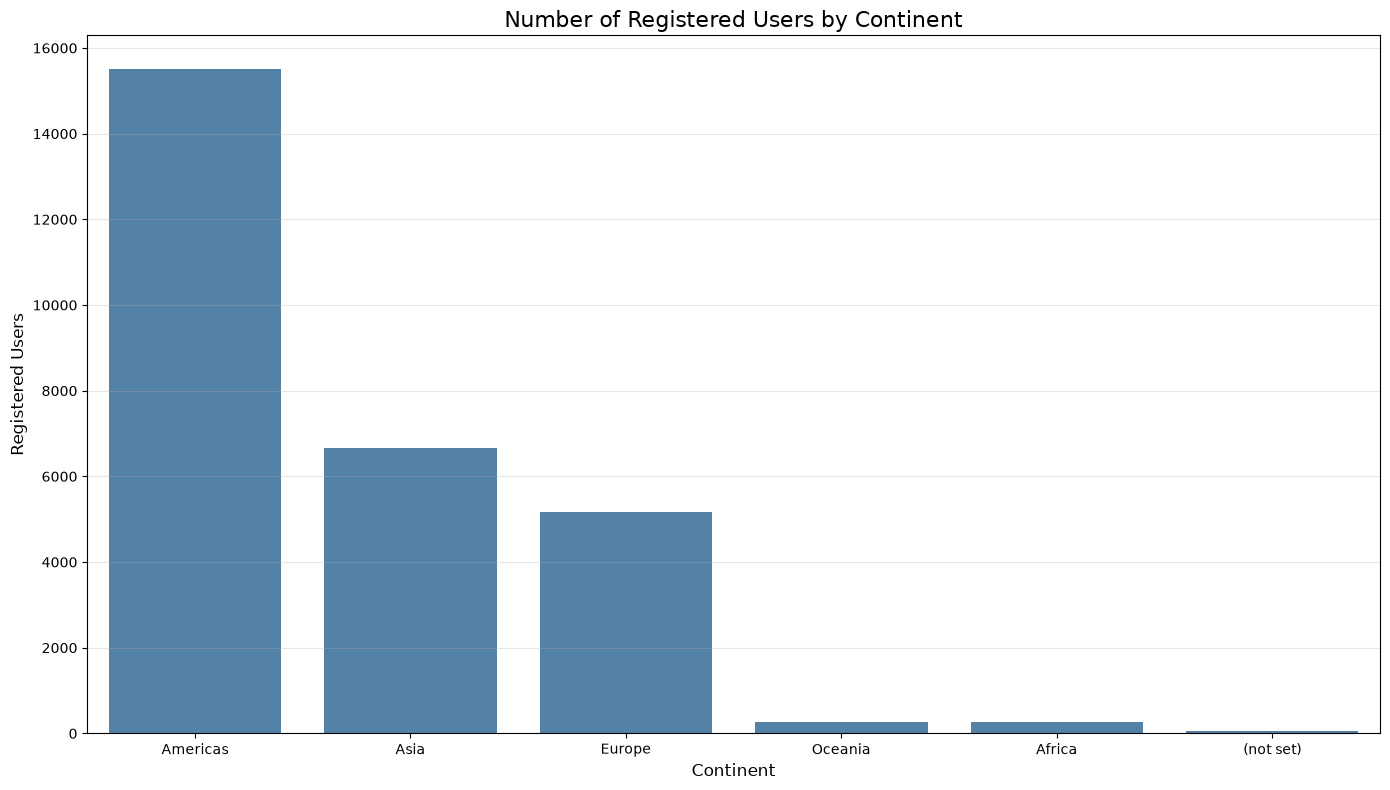

In [ ]:
## cheking number of registered users by continent 

# necessary aggregation 
reg_users_continent = (df.assign(registered=df["account_id"].notna())
      .groupby("continent")
      .agg(registered =("registered", "sum"))
      .sort_values(by="registered", ascending=False)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=reg_users_continent.index,
    y=reg_users_continent["registered"],
    color="steelblue"
)

plt.title(
    "Number of Registered Users by Continent",
    fontsize=16
)
plt.xlabel(
    "Continent",
    fontsize=12
)
plt.ylabel(
    "Registered Users",
    fontsize=12
)
plt.grid(which="major", axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**Registrations - Key Findings:**

* Almost 10% of all sessions are associated with registered users, while the vast majority of sessions are conducted by unregistered users.

* Around 70–75% of registered users have a confirmed email address. Among both confirmed and unconfirmed users, the majority remain subscribed to email communications. However, unsubscribed users represent a noticeably larger share among users with confirmed emails.

* Registration conversion is relatively consistent across all traffic channels, remaining close to 8%. Organic Search shows a slightly higher conversion rate than the other channels, but the difference is not substantial.

* The Americas have the highest number of registered users, followed by Asia and Europe. This ranking is consistent with the overall session distribution, suggesting that registration rates are broadly similar across the major continents.

* Device type also shows little variation in registration conversion, with rates remaining close to 8% across desktop, mobile, and tablet users. This suggests that device type is not a major differentiating factor in registration behavior within this dataset. This visualisation was excluded from the final notebook.

## 3.3 Revenue & Sales Analysis


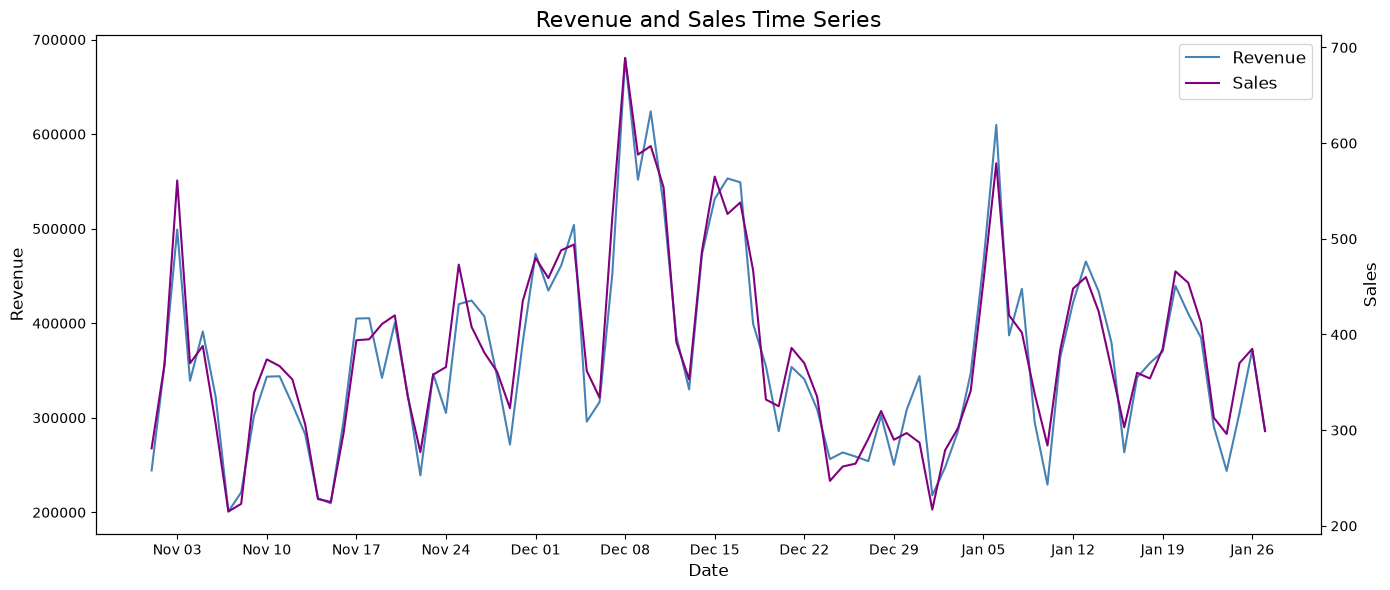

In [ ]:
## revenue and sales timeseries 
fig, ax1 = plt.subplots(figsize=(14, 6))

# revenue plot
sns.lineplot(
    x=df["date"],
    y=df["price"],
    estimator="sum",
    errorbar=None,
    color="steelblue",
    ax=ax1,
    legend=False
)

ax1.set_title(
    "Revenue and Sales Time Series",
    fontsize=16
)
ax1.set_xlabel(
    "Date",
    fontsize=12
)
ax1.set_ylabel(
    "Revenue",
    fontsize=12
)

# second y-axis
ax2 = ax1.twinx()

# sales plot
sns.lineplot(
    x=df["date"],
    y=df["price"],
    estimator="count",
    errorbar=None,
    color="purple",
    ax=ax2,
    legend=False
)

ax2.set_ylabel(
    "Sales",
    fontsize=12
)

# combined legend
ax1.legend(
    [ax1.lines[0], ax2.lines[0]],
    ["Revenue", "Sales"],
    loc="upper right",
    fontsize=12
)

ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

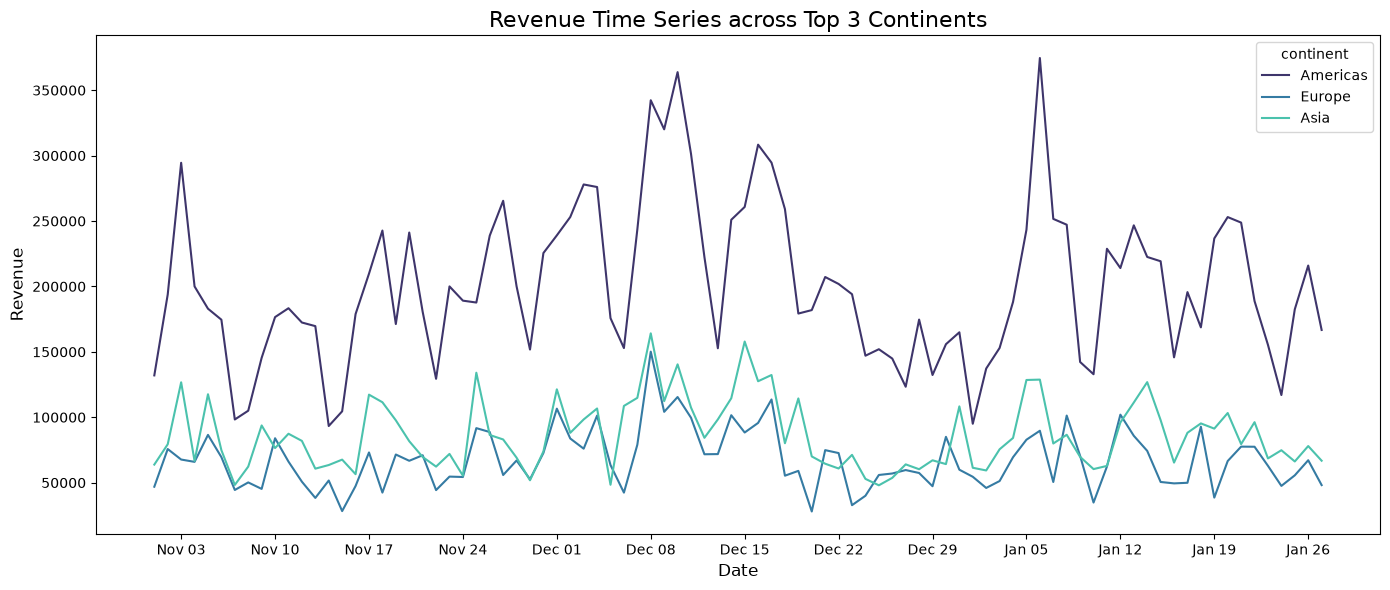

In [ ]:
## revenue timeseries across continents

# necessary aggregation 
top_3_continents_df = df[df["continent"].isin(["Americas", "Europe", "Asia"])]

plt.figure(figsize=(14, 6))

sns.lineplot(
    x=top_3_continents_df["date"],
    y=top_3_continents_df["price"],
    estimator="sum",
    errorbar=None,
    hue=top_3_continents_df["continent"],
    palette="mako"
)

plt.title(
    "Revenue Time Series across Top 3 Continents",
    fontsize=16
)
plt.xlabel(
    "Date",
    fontsize=12
)
plt.ylabel(
    "Revenue",
    fontsize=12
)

plt.gca().xaxis.set_major_locator(
    mdates.WeekdayLocator(interval=1)
)
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %d")
)

plt.tight_layout()
plt.show()

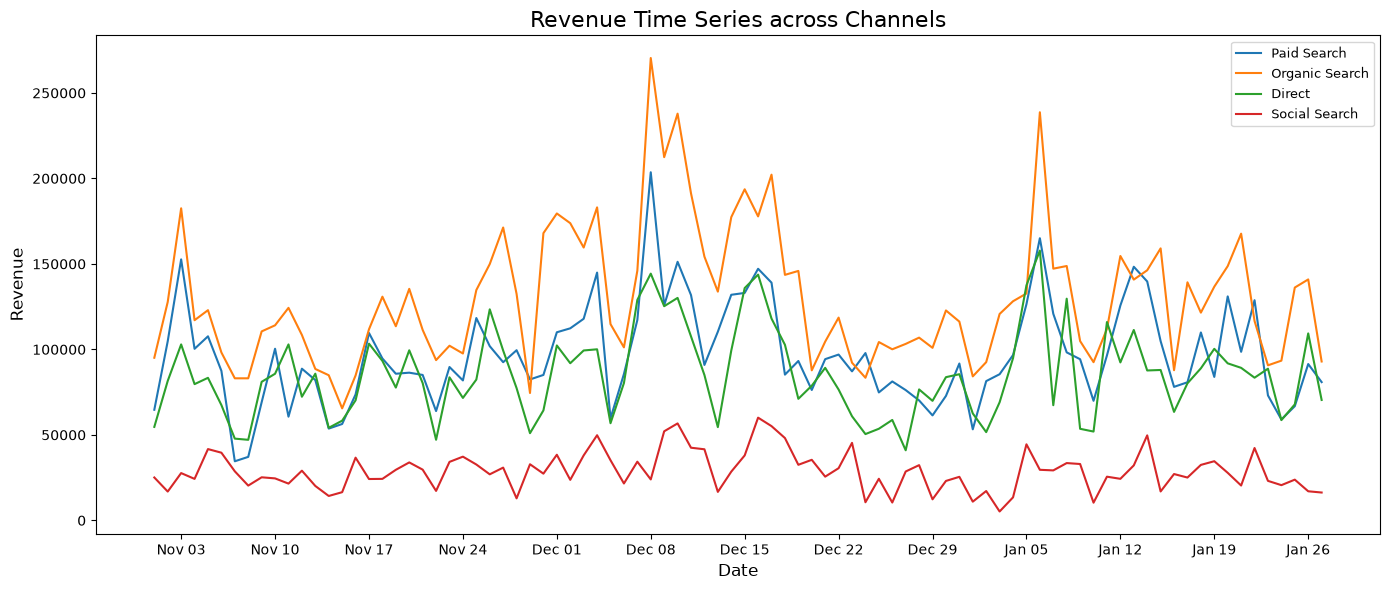

In [ ]:
# revenue timeseries across channels
plt.figure(figsize=(14, 6))

sns.lineplot(
    x=df["date"],
    y=df["price"],
    estimator="sum",
    errorbar=None,
    hue=df.loc[(df["channel"] != "Undefined"), "channel"],
    palette="tab10"
)

plt.title(
    "Revenue Time Series across Channels",
    fontsize=16
)
plt.xlabel(
    "Date",
    fontsize=12
)
plt.ylabel(
    "Revenue",
    fontsize=12
)

plt.gca().xaxis.set_major_locator(
    mdates.WeekdayLocator(interval=1)
)
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %d")
)

plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

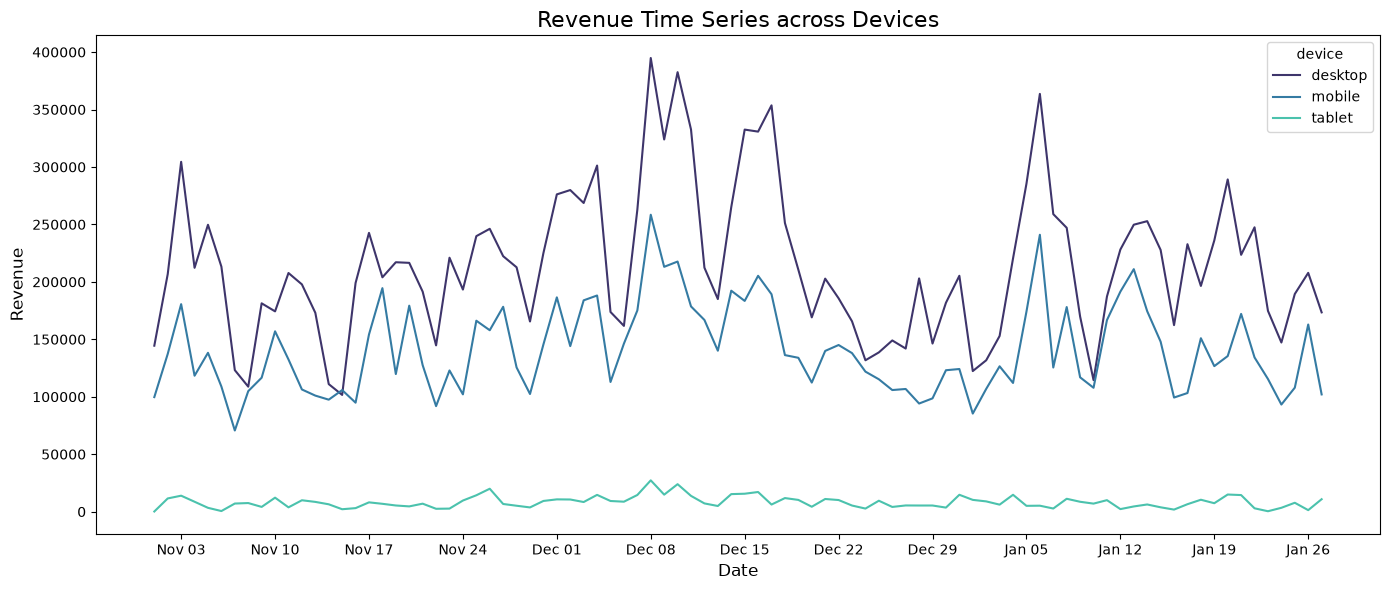

In [ ]:
# revenue timeseries across devices
plt.figure(figsize=(14, 6))

sns.lineplot(
    x=df["date"],
    y=df["price"],
    estimator="sum",
    errorbar=None,
    hue=df["device"],
    palette="mako"
)

plt.title(
    "Revenue Time Series across Devices",
    fontsize=16
)
plt.xlabel(
    "Date",
    fontsize=12
)
plt.ylabel(
    "Revenue",
    fontsize=12
)

plt.xticks(
    rotation=0
)

plt.gca().xaxis.set_major_locator(
    mdates.WeekdayLocator(interval=1)
)
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %d")
)

plt.tight_layout()
plt.show()

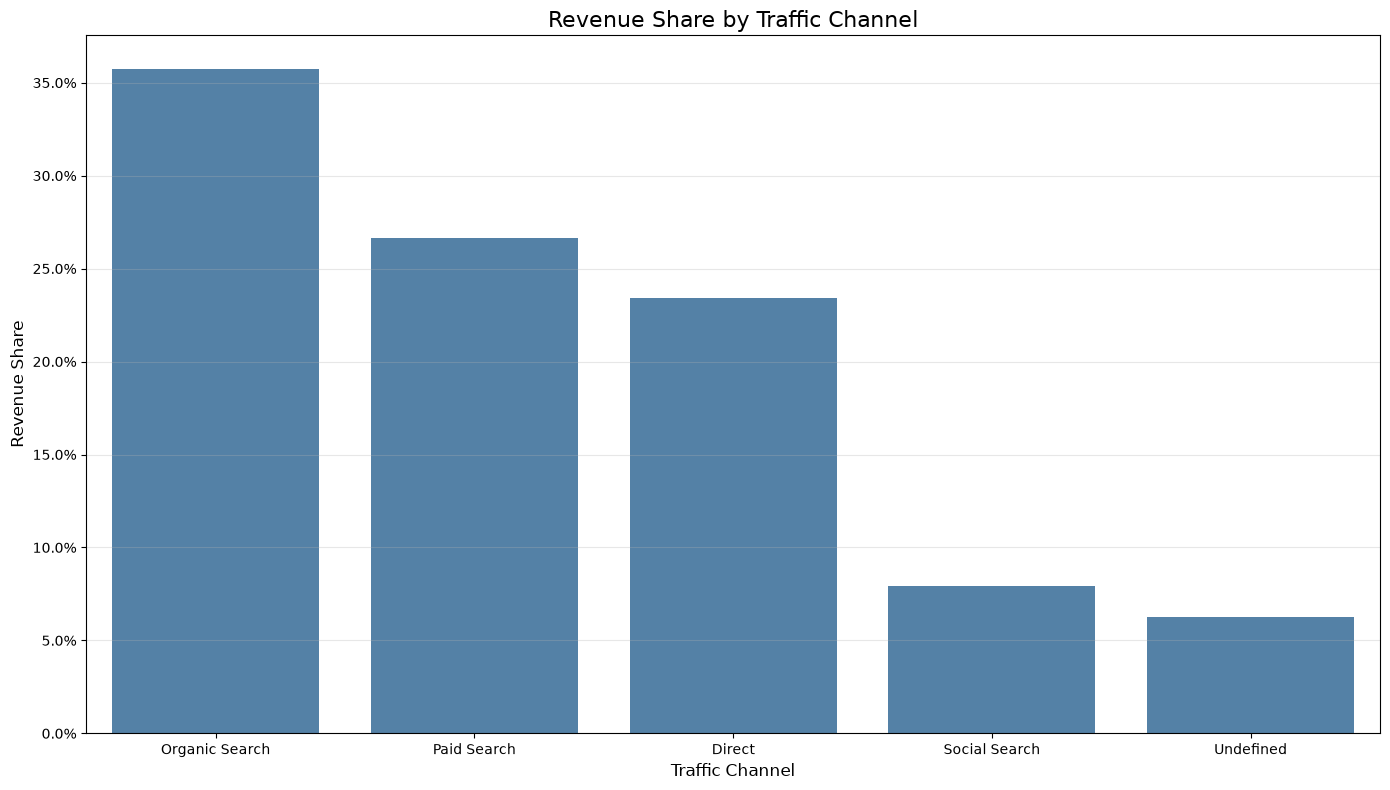

In [ ]:
## cheking revenue distribution across traffic channels

# necessary aggregation
revenue_channel = df.groupby("channel", as_index=False)["price"].sum()

revenue_channel["revenue_of_total"] = revenue_channel["price"] / revenue_channel["price"].sum() 

revenue_channel_order = (
    revenue_channel.sort_values(by="revenue_of_total", ascending=False)
    .set_index("channel", drop=True)).index

# plotting 
plt.figure(figsize=(14, 8))

sns.barplot(
    x=revenue_channel["channel"],
    y=revenue_channel["revenue_of_total"] * 100,
    order=revenue_channel_order,
    color="steelblue"
)

plt.title(
    "Revenue Share by Traffic Channel",
    fontsize=16
)
plt.xlabel(
    "Traffic Channel",
    fontsize=12
)
plt.ylabel(
    "Revenue Share",
    fontsize=12
)

plt.grid(which="major", axis="y", alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(100))

plt.tight_layout()
plt.show()

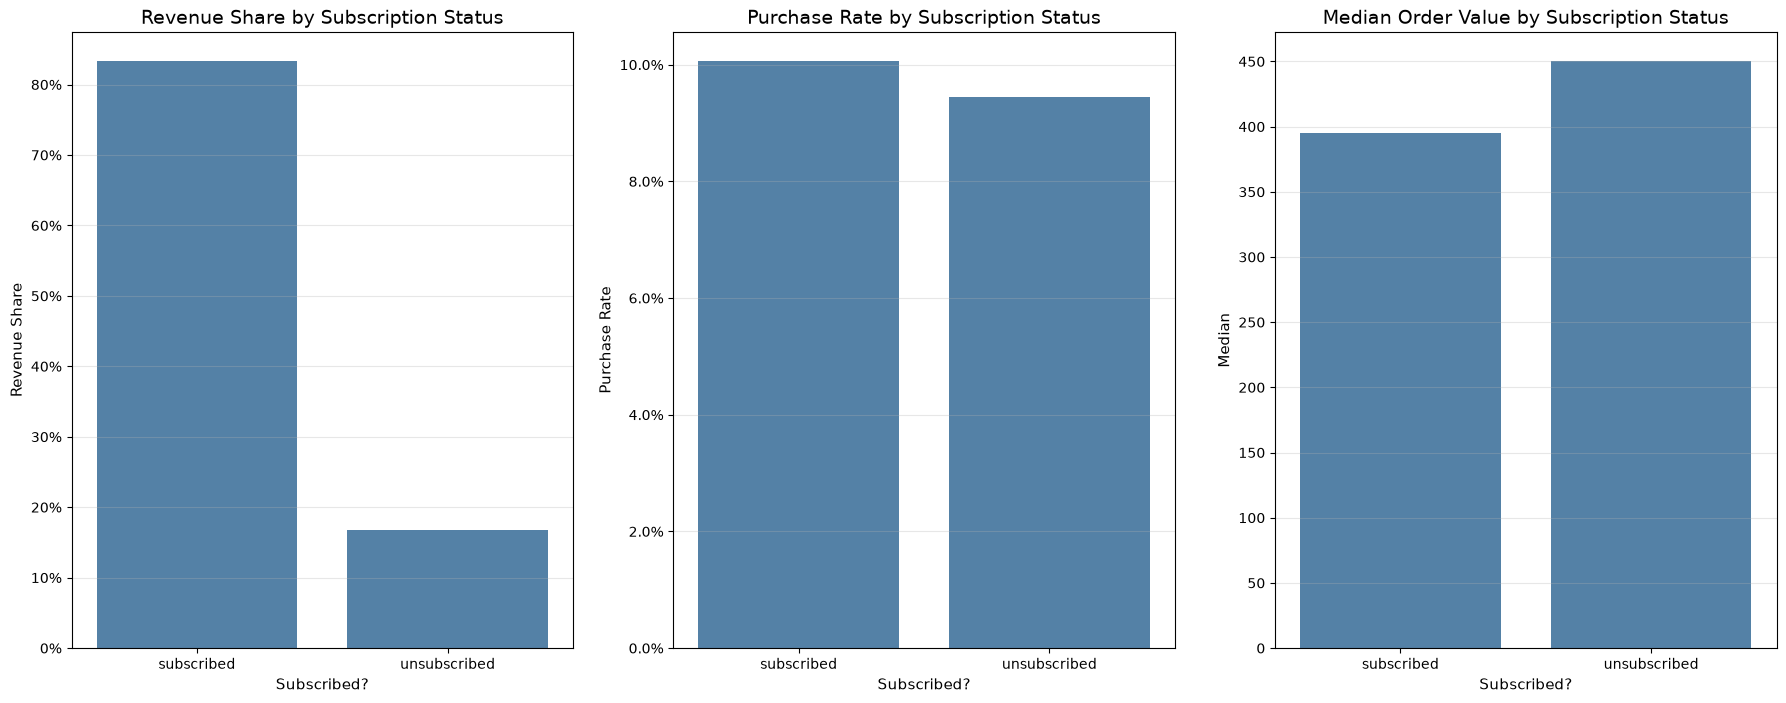

In [ ]:
## cheking buying behaviour for subscribed and unsubscribed users 

# necessary aggregation for plot 1
buying_behaviour_subscriptions = df.groupby(
    "is_unsubscribed", as_index=False)["price"].sum()

buying_behaviour_subscriptions["price"] = buying_behaviour_subscriptions["price"] / buying_behaviour_subscriptions["price"].sum()

buying_behaviour_subscriptions["is_unsubscribed"] = buying_behaviour_subscriptions["is_unsubscribed"].map({0: "subscribed", 1: "unsubscribed"})

# subplots settings 
fig, ax = plt.subplots(1, 3, figsize=(22, 8))

# plot 1
sns.barplot(
    x=buying_behaviour_subscriptions["is_unsubscribed"],
    y=buying_behaviour_subscriptions["price"] * 100,
    color="steelblue",
    ax=ax[0]
)

ax[0].set_title(
    "Revenue Share by Subscription Status",
    fontsize=14
)
ax[0].set_xlabel(
    "Subscribed?",
    fontsize=11 
)
ax[0].set_ylabel(
    "Revenue Share",
    fontsize=11
)

ax[0].grid(which="major", axis="y", alpha=0.3)
ax[0].yaxis.set_major_formatter(PercentFormatter(100))

# necessary aggregation for plot 2
purchase_rate_subscription = df.groupby("is_unsubscribed", as_index=False).agg(
    purchases=("price", "count"),
    sessions=("session_id", "count")
)
purchase_rate_subscription["purchase_rate"] = purchase_rate_subscription["purchases"] / purchase_rate_subscription["sessions"]

purchase_rate_subscription["is_unsubscribed"] = purchase_rate_subscription["is_unsubscribed"].map({0: "subscribed", 1: "unsubscribed"})

# plot 2 
sns.barplot(
    x=purchase_rate_subscription["is_unsubscribed"],
    y=purchase_rate_subscription["purchase_rate"] * 100,
    color="steelblue",
    ax=ax[1]
)

ax[1].set_title(
    "Purchase Rate by Subscription Status",
    fontsize=14
)
ax[1].set_xlabel(
    "Subscribed?",
    fontsize=11 
)
ax[1].set_ylabel(
    "Purchase Rate",
    fontsize=11
)

ax[1].grid(which="major", axis="y", alpha=0.3)
ax[1].yaxis.set_major_formatter(PercentFormatter(100))


# plot 3 
sns.barplot(
    x=df["is_unsubscribed"],
    y=df["price"],
    estimator="median",
    errorbar=None,
    color="steelblue",
    ax=ax[2]
)

ax[2].set_title(
    "Median Order Value by Subscription Status",
    fontsize=14
)
ax[2].set_xlabel(
    "Subscribed?",
    fontsize=11 
)
ax[2].set_ylabel(
    "Median",
    fontsize=11
)
ax[2].set_xticks(ticks=[0, 1], labels=["subscribed", "unsubscribed"])
ax[2].set_yticks(np.arange(0, 500, 50))

ax[2].grid(which="major", axis="y", alpha=0.3)

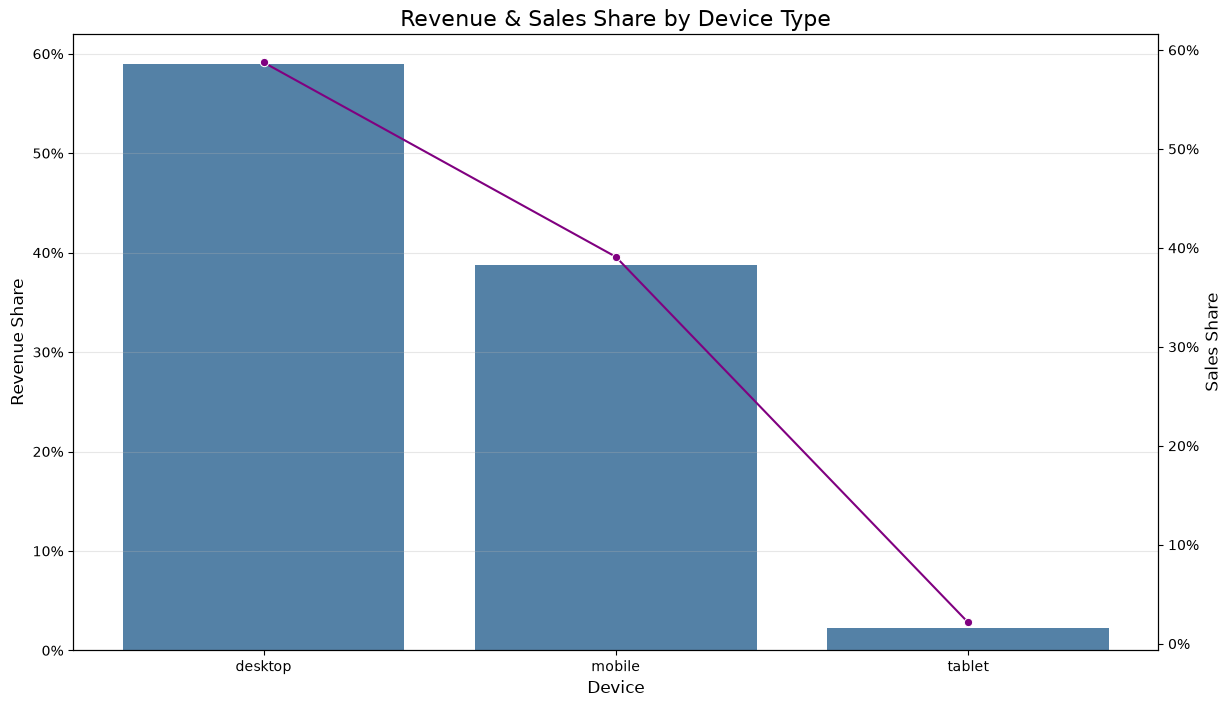

In [ ]:
## cheking revenue & sales share by device type

# necessary aggregation 
revenue_devices = df.groupby("device", as_index=False).agg(
    revenue=("price", "sum"),
    sales=("price", "count")
)

revenue_devices["revenue_of_total"] = revenue_devices["revenue"] / revenue_devices["revenue"].sum() * 100
revenue_devices["sales_of_total"] = revenue_devices["sales"] / revenue_devices["sales"].sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 8))

# revenue barplot
sns.barplot(
    x=revenue_devices["device"],
    y=revenue_devices["revenue_of_total"],
    color="steelblue",
    ax=ax1
)
ax1.set_title(
    "Revenue & Sales Share by Device Type",
    fontsize=16
)
ax1.set_xlabel(
    "Device",
    fontsize=12
)
ax1.set_ylabel(
    "Revenue Share",
    fontsize=12
)

ax1.grid(which="major", axis="y", alpha=0.3)
ax1.yaxis.set_major_formatter(PercentFormatter(100))

# second yaxis
ax2 = ax1.twinx()

# sales lineplot 
sns.lineplot(
    x=revenue_devices["device"],
    y=revenue_devices["sales_of_total"],
    marker="o",
    color="purple",
    ax=ax2
)
ax2.set_ylabel(
    "Sales Share",
    fontsize=12
)
ax2.yaxis.set_major_formatter(PercentFormatter(100))


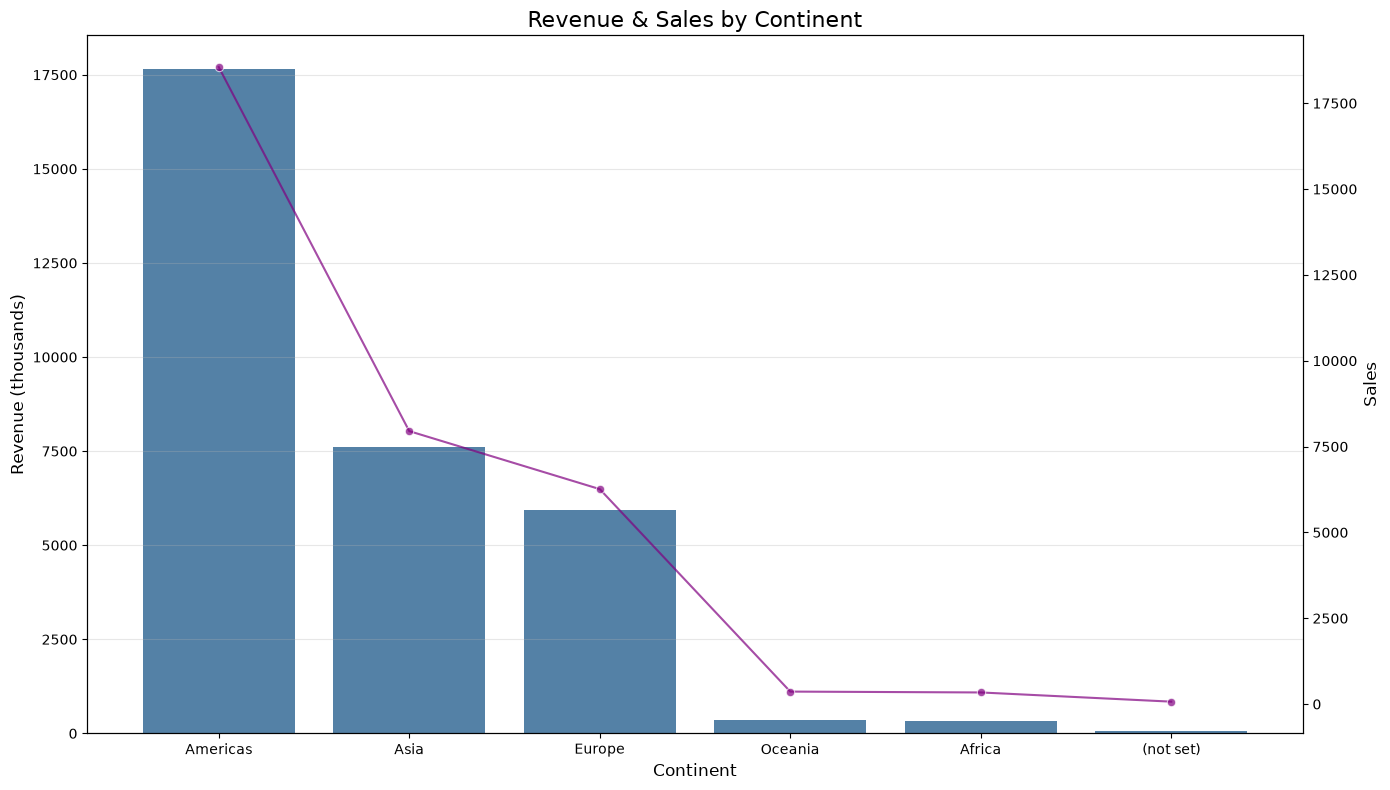

In [ ]:
# cheking revenue by continents 
continent_revenue_order = (
    df.groupby("continent")["price"]
    .sum()
    .sort_values(ascending=False)
    .index)

fig, ax1 = plt.subplots(figsize=(14, 8))

# plot 
sns.barplot(
    x=df["continent"],
    y=df["price"] / 1000,
    estimator="sum",
    errorbar=None,
    order=continent_revenue_order,
    color="steelblue",
    ax=ax1
)
ax1.set_title(
    "Revenue & Sales by Continent",
    fontsize=16
)
ax1.set_xlabel(
    "Continent",
    fontsize=12
)
ax1.set_ylabel(
    "Revenue (thousands)",
    fontsize=12
)

ax1.ticklabel_format(axis="y", style="plain")
ax1.grid(which="major", axis="y", alpha=0.3)

# second y-axis
ax2 = ax1.twinx()

# orders lineplot 
sns.lineplot(
    x=df["continent"],
    y=df["price"].notna(),
    estimator="sum",
    errorbar=None,
    marker="o",
    color="purple",
    alpha=0.7,
    ax=ax2
)

ax2.set_ylabel(
    "Sales",
    fontsize=12
)

plt.tight_layout()
plt.show()

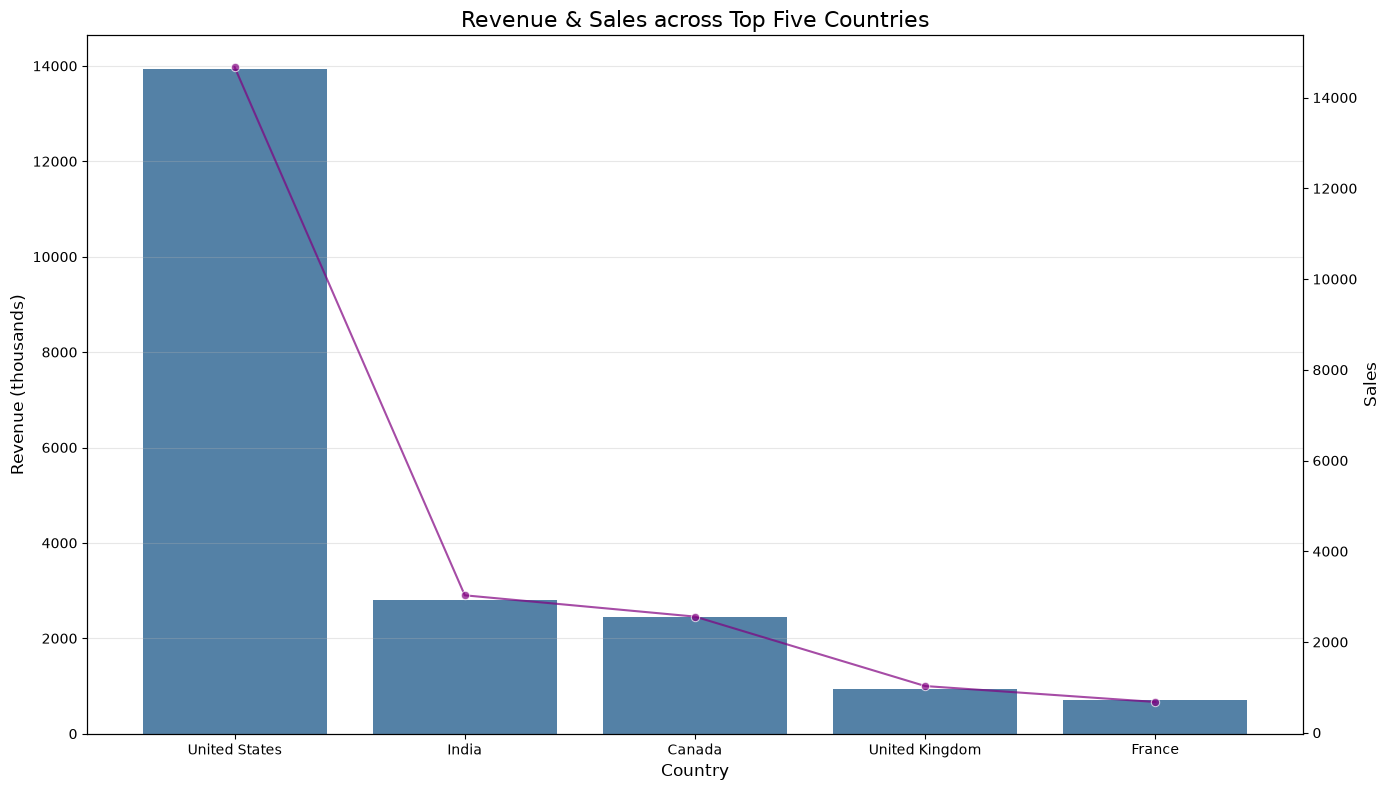

In [ ]:
## cheking revenue share across top 5 countries by revenue

# necessary aggregation
revenue_top_countries = (df.groupby("country")
                         .agg(revenue=("price", "sum"),
                              sales=("price", "count"))
                              .sort_values(by="revenue", ascending=False)
                              .iloc[:5, :])

fig, ax1 = plt.subplots(figsize=(14, 8))

# revenue barplot 
sns.barplot(
    x=revenue_top_countries.index,
    y=revenue_top_countries["revenue"] / 1000,
    color="steelblue",
    ax=ax1
)
ax1.set_title(
    "Revenue & Sales across Top Five Countries",
    fontsize=16
)
ax1.set_xlabel(
    "Country",
    fontsize=12
)
ax1.set_ylabel(
    "Revenue (thousands)",
    fontsize=12
)

ax1.ticklabel_format(axis="y", style="plain")
ax1.grid(which="major", axis="y", alpha=0.3)

# second y-axis
ax2 = ax1.twinx()

# orders lineplot 
sns.lineplot(
    x=revenue_top_countries.index,
    y=revenue_top_countries["sales"],
    marker="o",
    color="purple",
    alpha=0.7,
    ax=ax2
)

ax2.set_ylabel(
    "Sales",
    fontsize=12
)

plt.tight_layout()
plt.show()

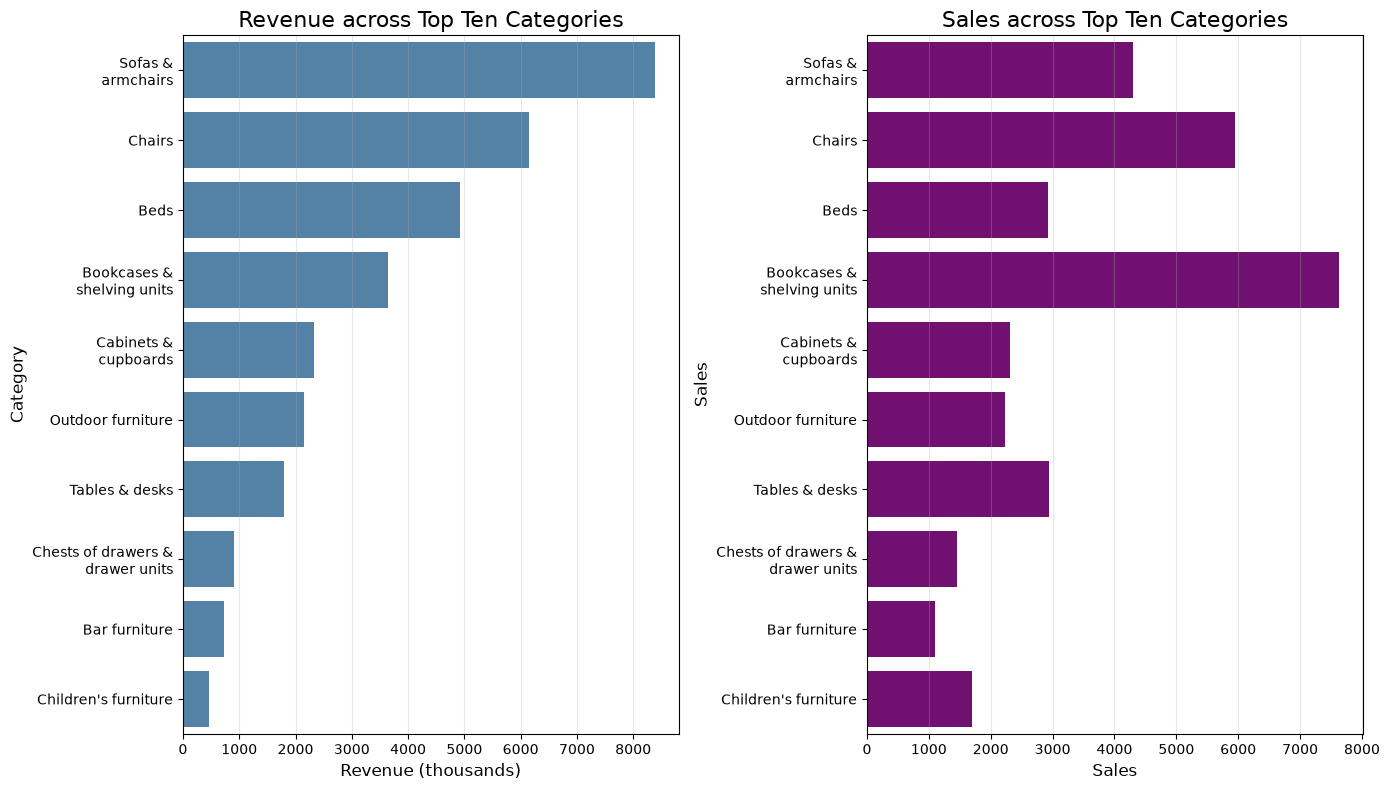

In [ ]:
## cheking revenue share across top 10 categories 

# necessary aggregation 
revenue_top_categories = (df.groupby("category", as_index=False)
                          .agg(revenue=("price", "sum"),
                               sales=("price", "count"))
                               .sort_values(by="revenue", ascending=False)
                               .iloc[:10, :])

revenue_top_categories["category"] = revenue_top_categories["category"].replace({
    "Chests of drawers & drawer units": "Chests of drawers &\ndrawer units",
    "Bookcases & shelving units": "Bookcases &\nshelving units",
    "Cabinets & cupboards": "Cabinets &\ncupboards",
    "Sofas & armchairs": "Sofas &\narmchairs"
})

fig, ax = plt.subplots(1, 2, figsize=(14, 8))

# revenue barplot
sns.barplot(
    x=revenue_top_categories["revenue"] / 1000,
    y=revenue_top_categories["category"],
    color="steelblue",
    ax=ax[0]
)
ax[0].set_title(
    "Revenue across Top Ten Categories",
    fontsize=16
)
ax[0].set_xlabel(
    "Revenue (thousands)",
    fontsize=12
)
ax[0].set_ylabel(
    "Category",
    fontsize=12
)

ax[0].ticklabel_format(axis="x", style="plain")
ax[0].grid(which="major", axis="x", alpha=0.3)

# sales barplot 
sns.barplot(
    x=revenue_top_categories["sales"],
    y=revenue_top_categories["category"],
    color="purple",
    ax=ax[1]
)
ax[1].set_title(
    "Sales across Top Ten Categories",
    fontsize=16
)
ax[1].set_xlabel(
    "Sales",
    fontsize=12
)
ax[1].set_ylabel(
    "Sales",
    fontsize=12
)
ax[1].grid(which="major", axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Revenue & Sales - Key Findings:**

* Revenue and sales volumes fluctuate considerably throughout the observation period, with the strongest peaks occurring in early November, December, and January. December represents the overall peak for both metrics, and major increases are typically followed by sharp declines.

* Organic Search is the largest revenue-generating traffic channel, accounting for over 35% of total revenue, followed by Paid Search and Direct. This distribution closely mirrors the traffic volume by channel, suggesting that revenue contribution is largely aligned with session volume.

* Subscribed users generate over 80% of total revenue, primarily due to their substantially larger user base. Despite this, their purchase rate is only slightly higher than that of unsubscribed users, while unsubscribed users have a higher median order value ($450 vs. $395). This indicates that the difference in revenue contribution is driven primarily by the size of the customer base rather than substantially different purchasing behavior.

* Desktop users account for almost 60% of total revenue, with revenue and sales shares closely matching the overall device distribution. This suggests that differences in revenue across device types are largely explained by differences in sales volume rather than materially different order values.

* The Americas generate the highest revenue and sales, followed by Asia and Europe. A similar ranking is observed at the country level, with the United States leading by a substantial margin, followed by India and Canada. Revenue and sales move broadly in the same direction across both geographic levels, indicating that sales volume is an important driver of revenue in these segments.

* Category performance reveals a notable difference between sales volume and revenue generation. Sofas & armchairs generate the highest revenue despite having fewer sales than Chairs and Bookcases & shelving units. In contrast, Bookcases & shelving units lead in sales but rank only fourth in revenue, indicating a substantially lower average order value compared with the leading revenue-generating categories.

# 4. Aggregated Tables


In [ ]:
## buyer behaviour by registration status pivot

# necessary aggregation
user_status_df = df.copy()
user_status_df["user_status"] = user_status_df["account_id"].notna().map({
    False: "guest",
    True: "registered"
})

buying_behaviour_registrations_pivot = pd.pivot_table(
    data=user_status_df, values=["price", "session_id"], index="user_status", aggfunc={
        "session_id": "count",
        "price": ["count", "sum"],
    }
)

buying_behaviour_registrations_pivot.columns = [
    "sales",
    "revenue",
    "sessions"
]

buying_behaviour_registrations_pivot["purchase_rate"] = (
    buying_behaviour_registrations_pivot["sales"] / 
    buying_behaviour_registrations_pivot["sessions"]
    ).round(4)

buying_behaviour_registrations_pivot["revenue_per_session"] = (
    buying_behaviour_registrations_pivot["revenue"] / 
    buying_behaviour_registrations_pivot["sessions"]
    ).round(4)

buying_behaviour_registrations_pivot = buying_behaviour_registrations_pivot[[
    "sessions",
    "sales",
    "revenue",
    "purchase_rate",
    "revenue_per_session"
]]

buying_behaviour_registrations_pivot

,sessions,sales,revenue,purchase_rate,revenue_per_session
user_status,,,,,
guest,321600,30757,29389212.6,0.0956,91.3844
registered,27945,2781,2582518.5,0.0995,92.4143


In [ ]:
## country x category sales & revenue pivot 

 # necessary aggregation
revenue_categories_countries = df.loc[(df["country"].isin(revenue_top_countries.index)) & (df["price"].notna()), ["country", "category", "price"]]

revenue_categories_countries_pivot = pd.pivot_table(
    data=revenue_categories_countries, values="price", index="category", columns="country", aggfunc=({
        "price": ["count", "sum"]
    })
)

revenue_categories_countries_pivot.columns = (
    revenue_categories_countries_pivot.columns.set_levels(
        ["sales", "revenue"], level=0
        )
)

revenue_categories_countries_pivot

sales                              \
country                              Canada France India United Kingdom   
category                                                                  
Bar furniture                            83     17    96             34   
Beds                                    218     56   236             97   
Bookcases & shelving units              591    144   734            232   
Cabinets & cupboards                    184     51   201             77   
Café furniture                           30      7    30             12   
Chairs                                  450    116   539            177   
Chests of drawers & drawer units        113     32   129             55   
Children's furniture                    116     46   142             42   
Nursery furniture                        32     14    31              8   
Outdoor furniture                       177     38   183             65   
Room dividers                             9      5    12              6   
Sideboards, buffets & console tables      7      1    13              5   
Sofas & armchairs                       331     91   396            137   
Tables & desks                          219     60   287             82   

                                                     revenue            \
country                              United States    Canada    France   
category                                                                 
Bar furniture                                  487   51724.0   11199.0   
Beds                                          1298  354772.0  116414.0   
Bookcases & shelving units                    3374  278981.9   73830.0   
Cabinets & cupboards                           995  181802.0   59101.5   
Café furniture                                 161   13368.0    2299.0   
Chairs                                        2576  417740.8  134029.4   
Chests of drawers & drawer units               616   71952.0   21544.5   
Children's furniture                           752   30264.0   14258.0   
Nursery furniture                              183   11090.0    4968.0   
Outdoor furniture                              984  185322.8   40486.4   
Room dividers                                   39   10168.0    2034.0   
Sideboards, buffets & console tables            57    5630.0     495.0   
Sofas & armchairs                             1903  692427.5  187735.0   
Tables & desks                                1248  132678.0   42299.0   

                                                                             
country                                  India United Kingdom United States  
category                                                                     
Bar furniture                          57657.0        22103.0      330805.0  
Beds                                  358319.5       133816.0     2213058.0  
Bookcases & shelving units            364507.4       113987.6     1567606.9  
Cabinets & cupboards                  191888.0        71684.5      994545.5  
Café furniture                         13738.0         4554.0       59000.0  
Chairs                                544309.2       188519.4     2619773.8  
Chests of drawers & drawer units       73111.0        36784.0      382388.0  
Children's furniture                   39177.0        13348.0      207575.0  
Nursery furniture                      11516.0         2775.0       65998.0  
Outdoor furniture                     162289.4        57002.4      929245.2  
Room dividers                           8072.0         5458.0       30439.0  
Sideboards, buffets & console tables   10590.0         4100.0       58110.0  
Sofas & armchairs                     788430.0       234812.0     3707144.5  
Tables & desks                        186157.5        49374.0      777865.0

In [ ]:
# product revenue & sales 
top_products_revenue_sales = (
    df.groupby("product_name")
    .agg(
        revenue=("price", "sum"),
        sales=("price", "count"))
        .sort_values(by="revenue", ascending=False)
        .iloc[:10, :])

max_products_sold = df["product_name"].value_counts().max()
min_products_sold = df["product_name"].value_counts().min()

print(f"Unique products: {df["product_name"].nunique()}")
print(f"The most amount of sales: {max_products_sold}")
print(f"The least amount of sales: {min_products_sold}")

top_products_revenue_sales

Unique products: 550
The most amount of sales: 1257
The least amount of sales: 2


,revenue,sales
product_name,,
GRÖNLID,2299190.0,915
LIDHULT,2257508.0,593
VIMLE,1710015.0,724
BESTÅ,1100634.5,1257
VALLENTUNA,1014376.0,412
KIVIK,877763.0,277
BEKANT,797761.0,491
HAVSTA,627430.0,418
SOLLERÖN,604380.0,250


In [ ]:
# continent x traffic channel revenue pivot 
continent_channel_revenue_pivot = pd.pivot_table(
    data=df, values="price", index="continent", columns="channel", aggfunc="sum"
)

continent_channel_revenue_pivot

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
continent,,,,,
(not set),21443.0,15080.0,19931.0,11224.4,6389.0
Africa,70028.0,129908.4,88195.0,31187.6,11912.0
Americas,4222962.0,6294563.2,4627454.3,1384427.7,1135872.8
Asia,1755294.5,2725953.8,2039256.5,576031.8,504761.7
Europe,1343093.9,2154138.6,1620206.1,498507.1,318678.5
Oceania,82102.0,113507.6,116006.5,30727.1,22887.0


**Aggregated Tables - Key Findings:**

* Guest sessions generate over 11 times more revenue than registered sessions, largely because the guest segment is over 11 times larger. Despite this difference in scale, purchase rates are very similar between the two groups (9.56% vs. 9.95%), while revenue per session is also nearly identical ($91.38 vs. $92.41). This indicates that the difference in total revenue is primarily driven by segment size rather than substantially different purchasing performance.

* Product performance reveals a substantial divergence between sales volume and revenue generation. BESTÅ is the most frequently purchased product, with 1,257 sales, yet it ranks considerably lower in revenue than higher-value products such as GRÖNLID and LIDHULT. This difference is driven by substantially higher revenue per sale for the latter products, demonstrating that sales volume alone does not determine revenue contribution.

* Revenue distribution across traffic channels varies by continent, although Organic Search is the leading revenue source across all major continents except Oceania, where Paid Search contributes slightly more. The Americas generate the largest revenue contribution across every channel, while Organic Search is particularly strong in the Americas and Asia. This suggests that both geographic scale and channel mix contribute to regional revenue performance.

# 5. Statistical Relationships Analysis

## 5.1 Sessions & Revenue Correlation by Day

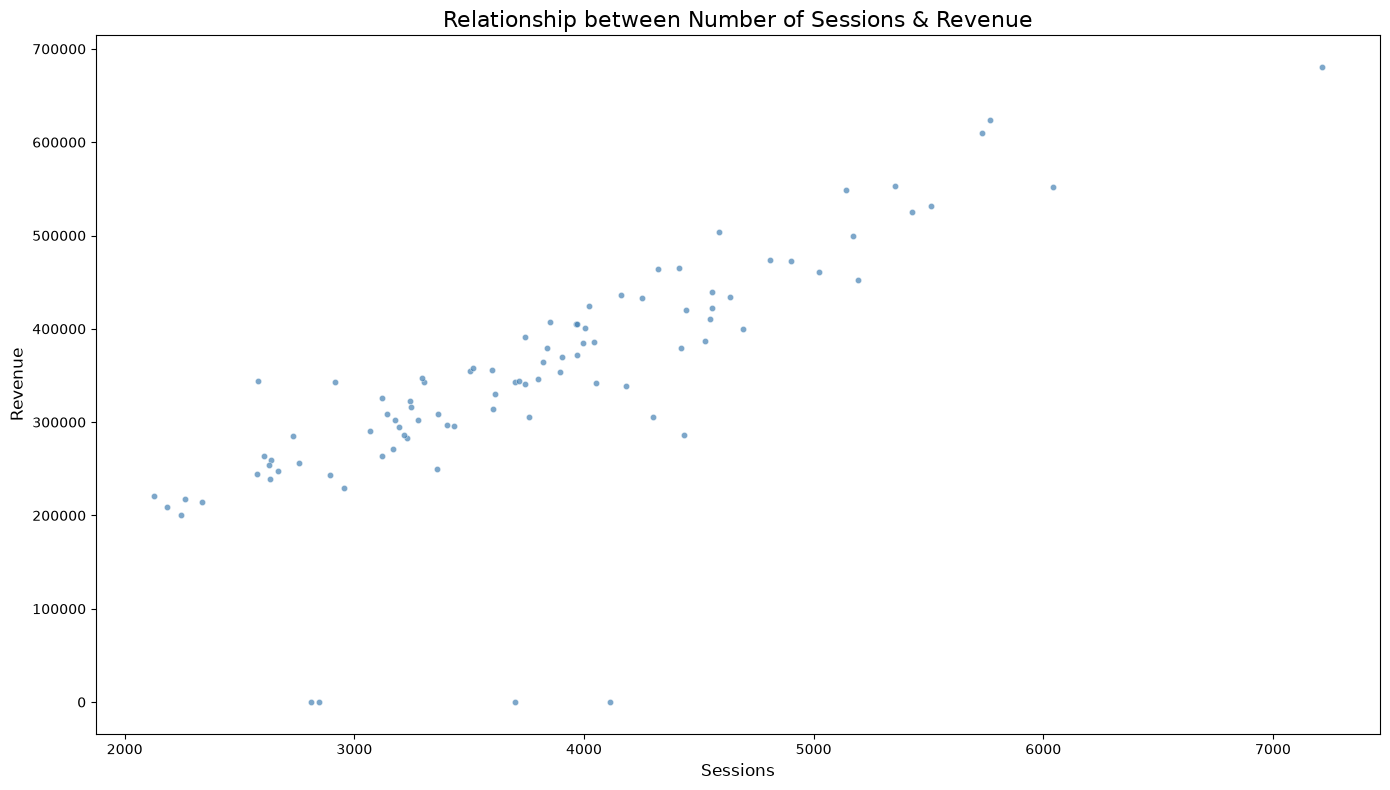

In [ ]:
## statistical relationship between total number of sessions and revenue by day 

# necessary aggregation 
sessions_revenue_day = df.groupby("date").agg(
    revenue=("price", "sum"),
    sessions=("session_id", "count")
)

# scatterplot
plt.figure(figsize=(14, 8))

sns.scatterplot(
    x=sessions_revenue_day["sessions"],
    y=sessions_revenue_day["revenue"],
    color="steelblue",
    s=20,
    alpha=0.7

)
plt.title(
    "Relationship between Number of Sessions & Revenue",
    fontsize=16
)
plt.xlabel(
    "Sessions",
    fontsize=12
)
plt.ylabel(
    "Revenue",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [ ]:
# cheking if datasets are normally distributed
_, p_value_1 = stats.normaltest(sessions_revenue_day["revenue"])

_, p_value_2 = stats.normaltest(sessions_revenue_day["sessions"])

print(f"Revenue p-value: {p_value_1:.4f}, Sessions p-value: {p_value_2:.4f}")

Revenue p-value: 0.0211, Sessions p-value: 0.0087


In [ ]:
# cheking correlation
pearson_sessions_revenue, p_pearson = stats.pearsonr(sessions_revenue_day["sessions"], sessions_revenue_day["revenue"])

spearman_sessions_revenue, p_spearman = stats.spearmanr(sessions_revenue_day["sessions"], sessions_revenue_day["revenue"])

print(f"Pearson correlation: {pearson_sessions_revenue:.4f}, P-value: {p_pearson:.4f}")
print(f"Spearman correlation: {spearman_sessions_revenue:.4f}, P-value: {p_spearman:.4f}")

Pearson correlation: 0.7911, P-value: 0.0000
Spearman correlation: 0.8653, P-value: 0.0000


**Relationship between Sessions & Revenue — Key Findings:**

* Visual inspection reveals a strong positive relationship between daily session volume and revenue. Days with higher numbers of sessions generally tend to generate higher revenue, although several observations deviate from the overall pattern.
* The D’Agostino–Pearson normality test indicates that neither variable follows a normal distribution (Revenue p = 0.0211, Sessions p = 0.0087). Pearson correlation was selected as the primary test because the research question focuses on the linear relationship between daily sessions and revenue. Spearman correlation was additionally performed as a robustness check due to the non-normal distributions and potential influence of extreme observations.
* Pearson correlation of 0.7911 indicates a strong positive linear association between daily sessions and revenue. Spearman correlation of 0.8653 indicates an even stronger positive monotonic association, confirming that the relationship remains strong when assessed using rank-based correlation.
* Both correlations are statistically significant (p < 0.001), providing strong evidence of an association between daily session volume and revenue. Overall, days with higher session volumes tend to coincide with higher revenue. However, correlation does not imply causation and does not establish that additional sessions directly cause higher revenue.

## 5.2 Daily Sales Correlation across Traffic Channels

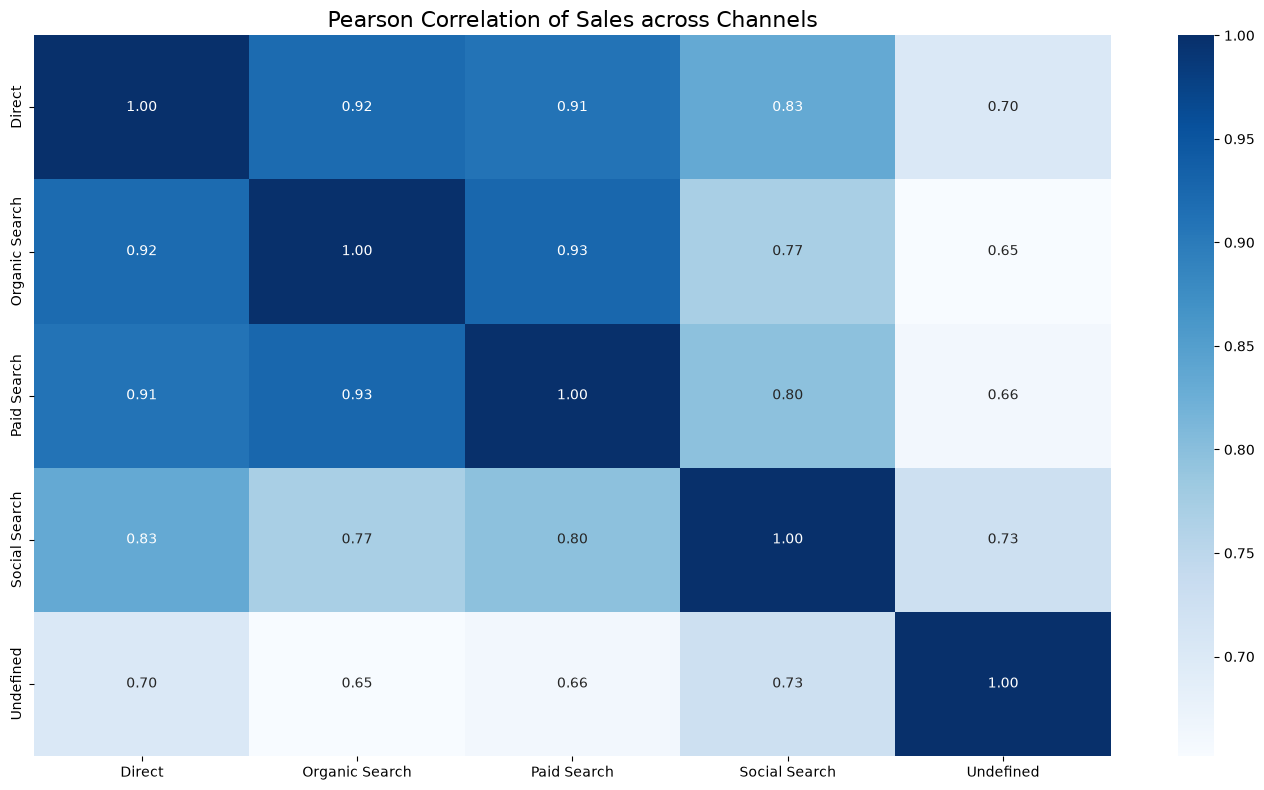

In [ ]:
## cheking correlation of sales across different traffic channels 

# necessary aggregation 
sales_day_channel = pd.pivot_table(
    df, 
    values="price", 
    index="date", 
    columns="channel", 
    aggfunc="count",
    fill_value=0
)

sales_day_channel = sales_day_channel.reindex(
    pd.date_range(df["date"].min(), df["date"].max()),
    fill_value=0
)

# pearson correlation plot
plt.figure(figsize=(14, 8))

sns.heatmap(
    sales_day_channel.corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title(
    "Pearson Correlation of Daily Sales across Channels",
    fontsize=16
)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
# cheking significance of statistical relationships
columns = sales_day_channel.columns

for i, channel in enumerate(columns):
    for next_channel in columns[i + 1:]:
        _, p = stats.pearsonr(
            sales_day_channel[channel],
            sales_day_channel[next_channel]
        )
        print(f"{channel} vs {next_channel} P-value = {p:.4f}")

Direct vs Organic Search P-value = 0.0000
Direct vs Paid Search P-value = 0.0000
Direct vs Social Search P-value = 0.0000
Direct vs Undefined P-value = 0.0000
Organic Search vs Paid Search P-value = 0.0000
Organic Search vs Social Search P-value = 0.0000
Organic Search vs Undefined P-value = 0.0000
Paid Search vs Social Search P-value = 0.0000
Paid Search vs Undefined P-value = 0.0000
Social Search vs Undefined P-value = 0.0000


**Sales across Traffic Channels - Key Findings:**

* Sales across all traffic channels demonstrate strong positive linear correlations with each other. The strongest relationship was observed between Organic Search and Paid Search (r = 0.93), while the weakest was between Organic Search and Social Search (r = 0.77). This indicates that sales across different channels tend to move in the same direction over time.

* Pearson correlation was selected because the objective of the analysis was to assess the linear relationship between daily sales across traffic channels. Although other correlation methods can be used to assess monotonic relationships, Pearson correlation directly addresses the relationship specified in the research question.

* All pairwise relationships were statistically significant (p < 0.001), indicating strong evidence that the observed correlations are unlikely to be explained by random variation alone. However, statistical significance does not imply that sales in one traffic channel cause changes in another; the results indicate that the channels exhibit similar sales dynamics over the observed period.

## 5.3 Daily Sales Correlation between Top 3 Continents

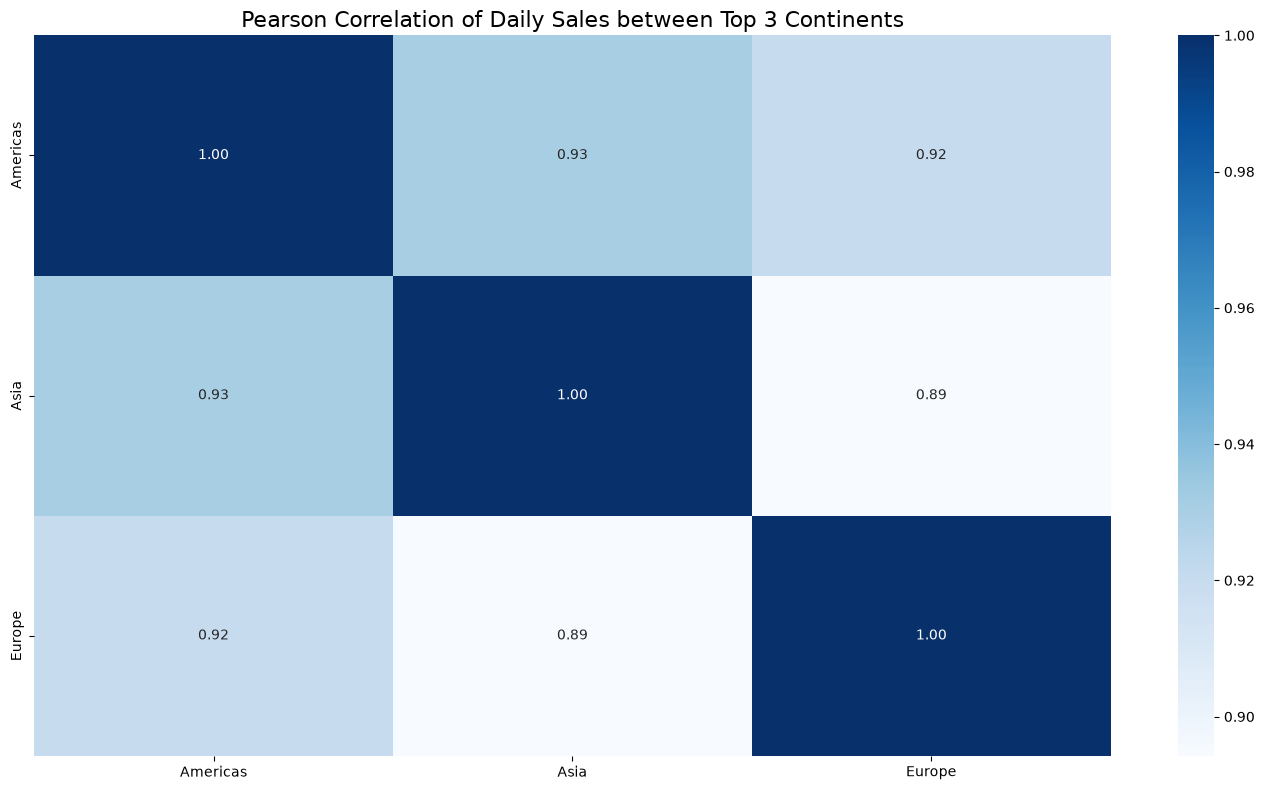

In [ ]:
## cheking daily sales correlation between top 3 continents

# creating dataframe 
continent_daily_sales = pd.pivot_table(
    df,
    values="price",
    index="date",
    columns="continent",
    aggfunc="count",
    fill_value=0
)

top_3_continents_sales = (df.groupby("continent")
                          ["price"]
                          .count()
                          .sort_values(ascending=False)
                          .iloc[:3]
                          .index)

continent_daily_sales = continent_daily_sales.loc[:, (continent_daily_sales.columns.isin(top_3_continents_sales))]

continent_daily_sales = continent_daily_sales.reindex(
    pd.date_range(df["date"].min(), df["date"].max()),
    fill_value=0
)

# pearson correlation plot
plt.figure(figsize=(14, 8))

sns.heatmap(
    continent_daily_sales.corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title(
    "Pearson Correlation of Daily Sales between Top 3 Continents",
    fontsize=16
)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()



In [ ]:
# cheking significance of statistical relationships
columns = continent_daily_sales.columns

for i, continent in enumerate(columns):
    for next_continent in columns[i + 1:]:
        _, p = stats.pearsonr(
            continent_daily_sales[continent],
            continent_daily_sales[next_continent]
        )
        print(f"{continent} vs {next_continent} P-value = {p:.4f}")

Americas vs Asia P-value = 0.0000
Americas vs Europe P-value = 0.0000
Asia vs Europe P-value = 0.0000


**Daily Sales Correlation between Top 3 Continents - Key Findings:**

* Daily sales demonstrate strong positive linear relationships across all three major continents. The strongest correlation is observed between **Americas and Asia** (`r = 0.93`), followed by **Americas and Europe** (`r = 0.92`) and **Asia and Europe** (`r = 0.89`).

* All three pairwise correlations are **statistically significant** (`p < 0.001`), providing strong evidence that daily sales across the continents tend to move together over the observed period.

* **Pearson correlation** was selected because the objective of the analysis was to assess the **linear relationship between daily sales** across continents. Overall, the results indicate that sales dynamics across the major markets are strongly aligned over time.

## 5.4 Daily Sales Correlation across Top 5 Products

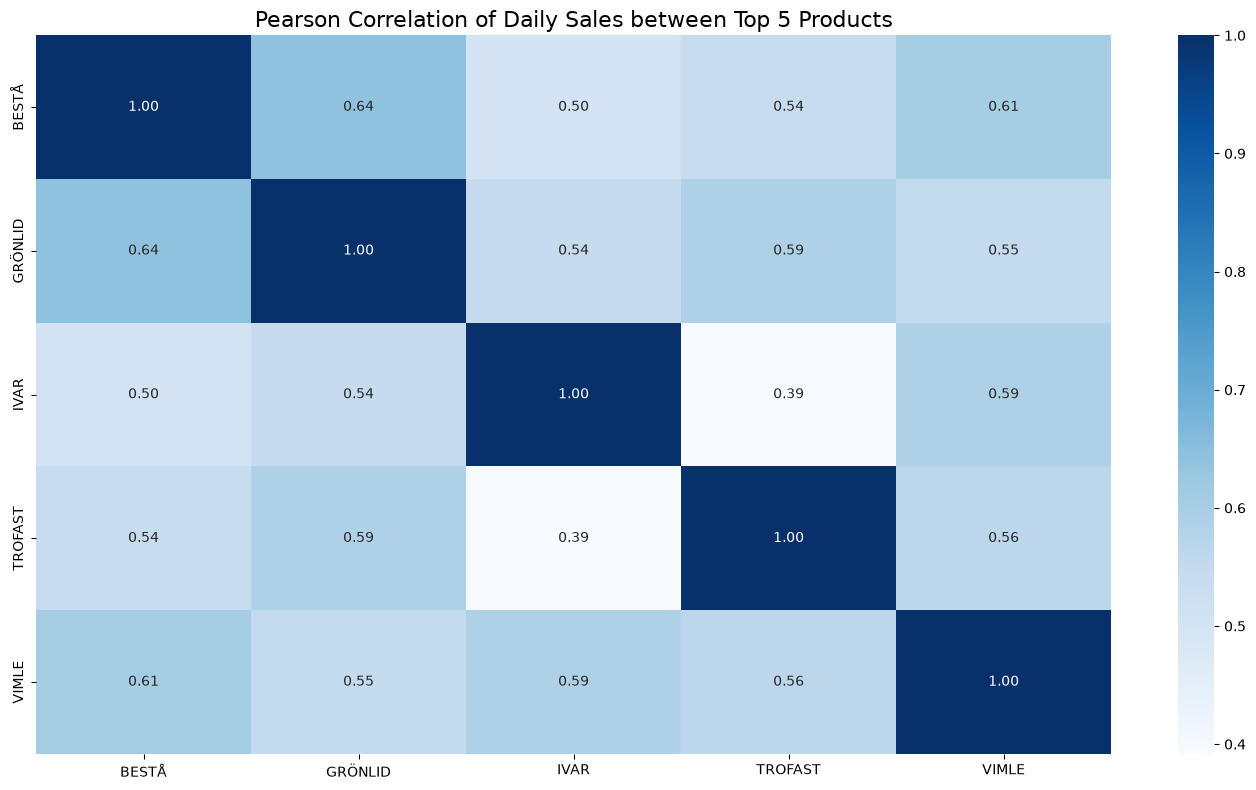

In [68]:
## cheking if daily sales across top 5 products tend to move together

# creating dataframe
products_daily_sales = pd.pivot_table(
    df,
    values="price",
    index="date",
    columns="product_name",
    aggfunc="count",
    fill_value=0
)

top_5_products_sales = (df.groupby("product_name")
                        ["price"]
                        .count()
                        .sort_values(ascending=False)
                        .iloc[:5]
                        .index)

products_daily_sales = products_daily_sales.loc[:, (products_daily_sales.columns.isin(top_5_products_sales))]

products_daily_sales = products_daily_sales.reindex(
    pd.date_range(df["date"].min(), df["date"].max()),
    fill_value=0
)

# pearson correlation plot
plt.figure(figsize=(14, 8))

sns.heatmap(
    products_daily_sales.corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title(
    "Pearson Correlation of Daily Sales between Top 5 Products",
    fontsize=16
)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [69]:
# cheking significance of statistical relationships
columns = products_daily_sales.columns

for i, product in enumerate(columns):
    for next_product in columns[i + 1:]:
        _, p = stats.pearsonr(
            products_daily_sales[product],
            products_daily_sales[next_product]
        )
        print(f"{product} vs {next_product} P-value = {p:.4f}")

BESTÅ vs GRÖNLID P-value = 0.0000
BESTÅ vs IVAR P-value = 0.0000
BESTÅ vs TROFAST P-value = 0.0000
BESTÅ vs VIMLE P-value = 0.0000
GRÖNLID vs IVAR P-value = 0.0000
GRÖNLID vs TROFAST P-value = 0.0000
GRÖNLID vs VIMLE P-value = 0.0000
IVAR vs TROFAST P-value = 0.0001
IVAR vs VIMLE P-value = 0.0000
TROFAST vs VIMLE P-value = 0.0000


**Daily Sales Correlation between Top 5 Products - Key Findings:**

* Daily sales across the top 5 products demonstrate **moderate positive linear correlations**, with Pearson correlation coefficients ranging from **0.39 to 0.64**. The strongest relationship was observed between **BESTÅ and GRÖNLID** (`r = 0.64`), while the weakest was between **IVAR and TROFAST** (`r = 0.39`).

* All pairwise correlations are **statistically significant** (`p < 0.001`), providing strong evidence that daily sales of the analyzed products tend to move together over the observed period.

* **Pearson correlation** was selected because the objective of the analysis was to assess the **linear relationship between daily sales** across products. The positive correlations indicate that higher sales of one product tend to coincide with higher sales of other products; however, correlation alone does not establish a causal or complementary relationship between the products.

## 5.5 Purchase Rate by User Status

In [ ]:
## cheking if there is statistical significant difference between sales across user status 

# necessary aggregation
purchase_rate_user_status = (
    user_status_df.groupby("user_status")
    .agg(
        sessions=("session_id", "count"),
        sales=("price", "count")
    )
)

# cheking actual purchase rates 
purchase_rate_user_status["purchase_rate"] = purchase_rate_user_status["sales"] / purchase_rate_user_status["sessions"]

registered_purchase_rate = purchase_rate_user_status.loc[
    "registered", "purchase_rate"
]
guest_purchase_rate = purchase_rate_user_status.loc[
    "guest", "purchase_rate"
]

print(f"Registered Group Purchase Rate: {registered_purchase_rate:.4%}")
print(f"Guest Group Purchase Rate: {guest_purchase_rate:.4%}\n")

# statistical significance of results
_, purchase_rate_pvalue = sm.stats.proportions_ztest(
    purchase_rate_user_status.loc[(["registered", "guest"], "sales")], 
    purchase_rate_user_status.loc[(["registered", "guest"], "sessions")]
)

if purchase_rate_pvalue <= 0.05:
    print(f"Difference in Purchase Rates between groups is statistically significant, p-value: {purchase_rate_pvalue:.4f}")
else:
    print(f"Difference in Purchase Rates between groups is statistically insignificant, p-value: {purchase_rate_pvalue:.4f}")

Registered Group Purchase Rate: 9.9517%
Guest Group Purchase Rate: 9.5637%

Difference in Purchase Rates between groups is statistically significant, p-value: 0.0347


**Purchase Rate by User Status - Key Findings:**

* Purchase rates are very similar between registered users and guests, with both groups remaining close to 10%. Registered users have a slightly higher purchase rate (9.95%) compared with guests (9.56%).

* The difference of approximately **0.39 percentage points** is statistically significant (`p = 0.0347`). However, the relatively small magnitude of the difference indicates limited practical significance.

* Guests generate approximately 11 times more sales in absolute terms, primarily because the guest group is substantially larger. After accounting for the difference in group size through purchase rates, there is no meaningful difference in purchasing behaviour between registered users and guests.

## 5.6 Organic Search Traffic Share Difference

In [ ]:
## cheking if difference in traffic share in organic search channel is significant (between Americas & Europe)

# creating dataframe 
traffic_share_continent = pd.pivot_table(
    df, 
    values="session_id", 
    index="continent", 
    columns="channel",
    aggfunc="count"
)

# necessary aggregations
organic_americas_sessions = traffic_share_continent.loc["Americas", "Organic Search"]
organic_europe_sessions = traffic_share_continent.loc["Europe", "Organic Search"]

americas_total_sessions = traffic_share_continent.loc["Americas", :].sum()
europe_total_sessions = traffic_share_continent.loc["Europe", :].sum()

americas_organic_share = (
    organic_americas_sessions / 
    americas_total_sessions
)
europe_organic_share = (
    organic_europe_sessions / 
    europe_total_sessions
)

# statistical test
_, organic_share_pvalue = sm.stats.proportions_ztest(
    [organic_americas_sessions, organic_europe_sessions],
    [americas_total_sessions, europe_total_sessions]
)

print(f"Americas Organic Search Traffic Share: {americas_organic_share:.4%}")
print(f"Europe Organic Search Traffic Share: {europe_organic_share:.4%}\n")

if organic_share_pvalue <= 0.05:
    print(f"Difference in Organic Search Traffic Share between groups is statistically significant, p-value: {organic_share_pvalue:.4f}")
else:
    print(f"Difference in Organic Search Traffic Share between groups is statistically insignificant, p-value: {organic_share_pvalue:.4f}")

Americas Organic Search Traffic Share: 35.5479%
Europe Organic Search Traffic Share: 35.6107%

Difference in Organic Search Traffic Share between groups is statistically insignificant, p-value: 0.7722


**Organic Search Traffic Share Difference - Key Findings:**

* Organic Search traffic shares are almost identical in the Americas and Europe, accounting for 35.55% and 35.61% of sessions, respectively.

* The difference of approximately **0.06 percentage points** is not statistically significant (`p = 0.7722`), indicating that there is insufficient evidence to conclude that Organic Search has a different traffic share between the Americas and Europe.

## 5.7 Average Daily Sessions across Traffic Channels

In [ ]:
## cheking if there is statistically significant difference of users per day across traffic channels

# creating data frame
sessions_day_channel = pd.pivot_table(
    df,
    index="date",
    columns="channel",
    values="session_id",
    aggfunc="count",
    fill_value=0
)

# ANOVA test 
_, anova_channels_pvalue = stats.f_oneway(
    sessions_day_channel["Direct"],
    sessions_day_channel["Organic Search"],
    sessions_day_channel["Paid Search"],
    sessions_day_channel["Social Search"],
    sessions_day_channel["Undefined"]
)

for channel in sessions_day_channel.columns.to_list():
    print(
        f"Average Daily Sessions from {channel} channel: "
        f"{sessions_day_channel[channel].mean():.2f}")

if anova_channels_pvalue >= 0.05:
    print(f"\nDifference in Average Daily Sessions across Channels is not significant, p-value: {anova_channels_pvalue:.4f}")
else:
    print(f"\nDifference in Average Daily Sessions across Channels is significant, p-value: {anova_channels_pvalue:.4f}")

Average Daily Sessions from Direct channel: 884.59
Average Daily Sessions from Organic Search channel: 1352.45
Average Daily Sessions from Paid Search channel: 1025.45
Average Daily Sessions from Social Search channel: 303.41
Average Daily Sessions from Undefined channel: 233.51

Difference in Average Daily Sessions across Channels is significant, p-value: 0.0000


**Average Daily Sessions across Traffic Channels - Key Findings:**

* Average daily session volume differs substantially across traffic channels. Organic Search has the highest average with approximately **1,352 sessions per day**, followed by Paid Search (**1,025**) and Direct (**885**). Social Search and Undefined have considerably lower averages of **303** and **234 sessions per day**, respectively.

* A **one-way ANOVA** was conducted to test whether the mean daily session volume differs across traffic channels. The test returned a statistically significant result (`p < 0.001`), providing strong evidence that average daily session volumes are not equal across the channels.

* The results confirm that traffic channels contribute substantially different volumes of sessions on a daily basis. However, ANOVA only establishes that **at least one channel differs from the others**; it does not identify which specific channel pairs are significantly different. Post-hoc testing would be required to determine the individual pairwise differences.

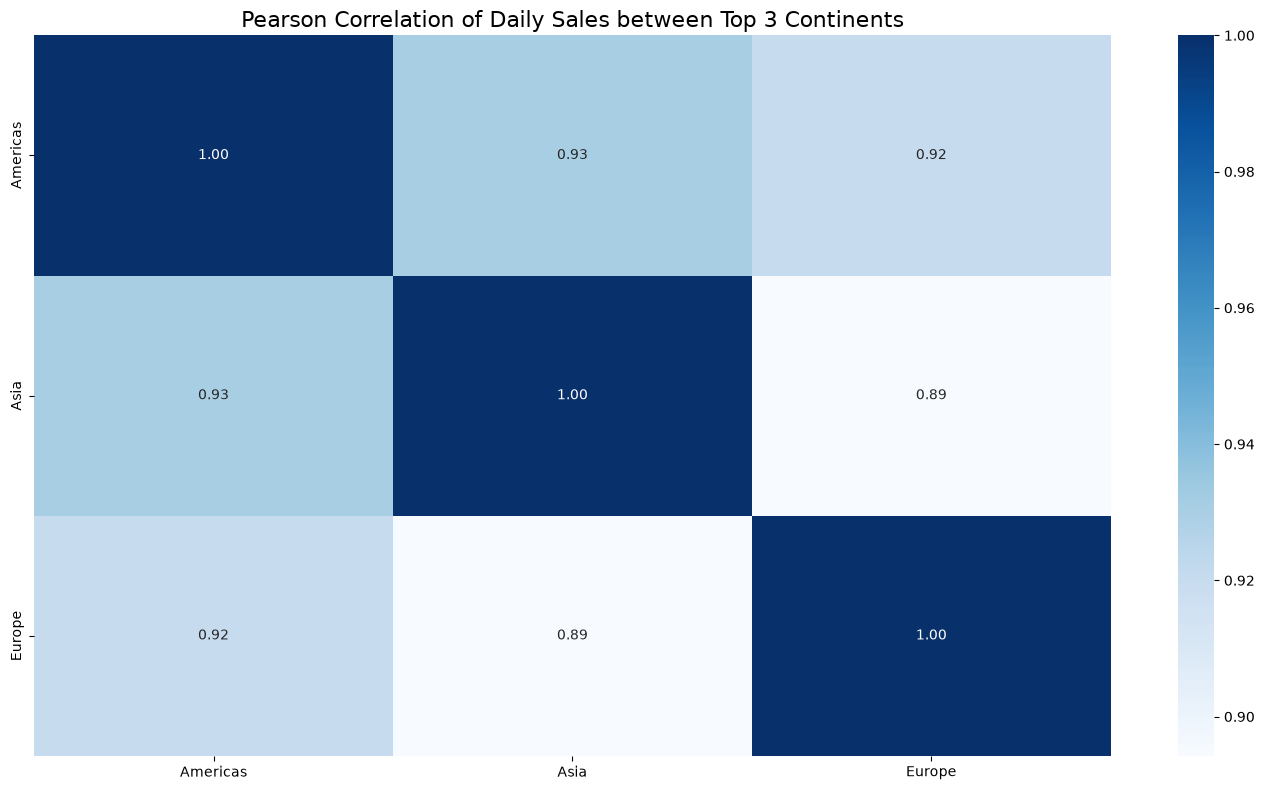

In [61]:
## cheking daily sales correlation between top 3 continents

# creating dataframe 
continent_daily_sales = pd.pivot_table(
    df,
    values="price",
    index="date",
    columns="continent",
    aggfunc="count",
    fill_value=0
)

top_3_continents_sales = (df.groupby("continent")
                          ["price"]
                          .count()
                          .sort_values(ascending=False)
                          .iloc[:3]
                          .index)

continent_daily_sales = continent_daily_sales.loc[:, (continent_daily_sales.columns.isin(top_3_continents_sales))]

# correlation heatmap
continent_daily_sales = continent_daily_sales.reindex(
    pd.date_range(df["date"].min(), df["date"].max()),
    fill_value=0
)

# pearson correlation plot
plt.figure(figsize=(14, 8))

sns.heatmap(
    continent_daily_sales.corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title(
    "Pearson Correlation of Daily Sales between Top 3 Continents",
    fontsize=16
)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()



In [62]:
# cheking significance of statistical relationships
columns = continent_daily_sales.columns

for i, continent in enumerate(columns):
    for next_continent in columns[i + 1:]:
        _, p = stats.pearsonr(
            continent_daily_sales[continent],
            continent_daily_sales[next_continent]
        )
        print(f"{continent} vs {next_continent} P-value = {p:.4f}")

Americas vs Asia P-value = 0.0000
Americas vs Europe P-value = 0.0000
Asia vs Europe P-value = 0.0000


# 6. General Business Findings

* **Traffic volume is strongly associated with revenue performance.** Daily sessions and revenue demonstrate a strong positive linear relationship (`Pearson r = 0.79`, `p < 0.001`), indicating that periods with higher traffic generally coincide with higher revenue.

* **Geographic scale is a major driver of overall sales and revenue.** The Americas generate the highest number of sessions, sales, and revenue, followed by Asia and Europe. The United States is the dominant country-level market, followed by India and Canada. This consistency across traffic and revenue metrics suggests that differences in market scale play an important role in overall business performance.

* **Organic Search is the leading traffic and revenue channel, with broadly consistent performance across regions.** Organic Search accounts for over 35% of both traffic and revenue and remains the leading revenue-generating channel across the major continents. Sales across traffic channels also exhibit strong positive correlations (`r = 0.77–0.93`), indicating that different channels tend to follow similar sales dynamics over time. Furthermore, Organic Search traffic share does not differ significantly between the Americas and Europe (`35.55% vs. 35.61%`, `p = 0.7722`).

* **User segment size has a much greater impact on total revenue than differences in purchasing behavior.** Guests account for a substantially larger share of sessions and generate approximately 11 times more total revenue than registered users. However, purchase rates are very similar between the two groups (`9.56% vs. 9.95%`), and revenue per session is also nearly identical (`$91.38 vs. $92.41`). Although the difference in purchase rates is statistically significant (`p = 0.0347`), its practical magnitude is small.

* **Product mix creates substantial differences between sales volume and revenue contribution.** Bookcases & Shelving units generate the highest number of sales but rank only fourth in total revenue, while Sofas & Armchairs generate the highest revenue despite having fewer sales. This indicates that revenue performance depends not only on sales volume but also on differences in revenue generated per sale across product categories.

* **Overall business performance is primarily characterized by scale and volume effects, while purchasing behavior remains relatively consistent across major segments.** The strongest patterns in the dataset are concentrated around traffic volume, geographic scale, channel contribution, and product mix. At the same time, statistical testing shows that some apparent differences between segments or regions are either small in practical terms or not statistically significant, highlighting the importance of distinguishing meaningful business differences from differences driven primarily by sample size or overall scale.

# 7. Data Prepatation for Tableau

In [ ]:
# main dataset
df_tableau = df.copy()

df_tableau["user_status"] = (
    df_tableau["account_id"]
    .notna()
    .map({
        False: "Guest",
        True: "Registered"
    }))

df_tableau = df_tableau[[
 'date',
 'session_id',
 'continent',
 'country',
 'device',
 'browser',
 'system',
 'channel',
 'account_id',
 'user_status',
 'confirmed_email',
 'is_unsubscribed',
 'category',
 'product_name',
 'price'
]]

# df_tableau.to_csv(
#     "/Users/kovalskyy/Downloads/Portfolio Project 1 (Mate)/data_sources_tableau/ecommerce_cleaned.csv",
#     index=False
# )

print("Tableau dataset exported successfully.")

Tableau dataset exported successfully.
